# Client Churn Prediction & Retention Strategy Optimization

**Highspring — Content Strategy & Client Advisory (Gurugram)**

Goal: predict which external clients (advertisers, publishers, website owners) are likely
to churn from our Google Search content-quality advisory service, explain the main drivers,
and map at-risk clients to concrete retention actions.

**Honest framing:** we have no real Highspring client data. The public IBM Telco churn
dataset is used as a *structural base* and re-framed as B2B client data. All behavioural
business features (content quality, engagement, support, search performance) are
**synthetic** — see *Part 2* for exactly how they are generated. What this notebook
validates is the pipeline, thresholds and segmentation logic; the absolute numbers are not
real Highspring performance.

In [1]:
# ---------- Setup: imports, seed, folders ----------
import os
import json
import time
import warnings
import datetime
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42  # one seed for everything
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Folder structure for run artifacts (relative paths only)
for d in ["data/processed", "models", "reports/figures"]:
    os.makedirs(d, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
sns.set_palette("deep")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

print("Environment ready | seed =", SEED)
print("Run date:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))

Environment ready | seed = 42
Run date: 2026-09-23 23:29


In [2]:
# ---------- Helpers: metrics, figure saving, threshold search ----------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

RUN_METRICS = {}  # everything in here is exported to reports/metrics.json at the end


def save_fig(fig, name):
    # Save a figure into reports/figures/ and show it inline
    path = f"reports/figures/{name}.png"
    fig.savefig(path, bbox_inches="tight")
    print("saved:", path)
    plt.show()


def metrics_at_threshold(y_true, proba, threshold):
    # All classification metrics at a fixed decision threshold
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    return {
        "threshold": round(float(threshold), 4),
        "accuracy": round(float(accuracy_score(y_true, pred)), 4),
        "precision": round(float(precision_score(y_true, pred, zero_division=0)), 4),
        "recall": round(float(recall_score(y_true, pred, zero_division=0)), 4),
        "f1": round(float(f1_score(y_true, pred, zero_division=0)), 4),
        "roc_auc": round(float(roc_auc_score(y_true, proba)), 4),
        "pr_auc": round(float(average_precision_score(y_true, proba)), 4),
        "confusion_matrix": {
            "tn": int(cm[0, 0]), "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
        },
    }


def best_threshold_by_f1(y_true, proba):
    # Threshold (sweeping the PR curve) that maximises F1
    from sklearn.metrics import precision_recall_curve
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1 = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
    return float(thr[int(np.argmax(f1[:-1]))])


def best_threshold_by_cost(y_true, proba, fn_cost=5.0, fp_cost=1.0):
    # Threshold minimising business cost: missed churner costs 5x a wasted outreach
    thresholds = np.linspace(0.01, 0.99, 99)
    costs = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        fn = int(((pred == 0) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        costs.append(fn_cost * fn + fp_cost * fp)
    costs = np.array(costs)
    return float(thresholds[int(np.argmin(costs))]), float(costs.min())


print("helpers ready")

helpers ready


## Part 1 — Load & inspect the base data

The IBM Telco customer churn dataset is our stand-in for a client roster. Note: the file in
`Data/` carries a `.csv` name but is actually an Excel workbook, so we read it with
`pd.read_excel`.

In [3]:
import pandas as pd

file_path = "Data/Telco_customer_churn.csv"

df = pd.read_excel(file_path)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
# Basic overview
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (7043, 33)

Columns:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [5]:
# Data types + non-null values
print("\nInfo:")
df.info()


Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-

In [6]:
# First 5 rows
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [7]:
# Missing values
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))


Missing values:


Churn Reason         5174
Online Security         0
CLTV                    0
Churn Score             0
Churn Value             0
Churn Label             0
Total Charges           0
Monthly Charges         0
Payment Method          0
Paperless Billing       0
Contract                0
Streaming Movies        0
Streaming TV            0
Tech Support            0
Device Protection       0
Online Backup           0
CustomerID              0
Count                   0
Multiple Lines          0
Phone Service           0
Tenure Months           0
Dependents              0
Partner                 0
Senior Citizen          0
Gender                  0
Longitude               0
Latitude                0
Lat Long                0
Zip Code                0
City                    0
State                   0
Country                 0
Internet Service        0
dtype: int64

In [8]:
# Unique values
print("\nUnique values:")
display(df.nunique().sort_values())


Unique values:


Count                   1
Country                 1
State                   1
Senior Citizen          2
Churn Value             2
Churn Label             2
Paperless Billing       2
Gender                  2
Partner                 2
Dependents              2
Phone Service           2
Online Backup           3
Online Security         3
Streaming TV            3
Multiple Lines          3
Internet Service        3
Device Protection       3
Contract                3
Streaming Movies        3
Tech Support            3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6531
CustomerID           7043
dtype: int64

In [9]:
# Numerical summary
print("\nNumerical summary:")
display(df.describe().T)


Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [10]:
categorical_cols = df.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].unique())


CustomerID
<ArrowStringArray>
['3668-QPYBK', '9237-HQITU', '9305-CDSKC', '7892-POOKP', '0280-XJGEX', '4190-MFLUW', '8779-QRDMV', '1066-JKSGK', '6467-CHFZW', '8665-UTDHZ',
 ...
 '0871-OPBXW', '3605-JISKB', '9767-FFLEM', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO', '6840-RESVB', '2234-XADUH', '4801-JZAZL', '3186-AJIEK']
Length: 7043, dtype: str

Country
<ArrowStringArray>
['United States']
Length: 1, dtype: str

State
<ArrowStringArray>
['California']
Length: 1, dtype: str

City
<ArrowStringArray>
[    'Los Angeles',   'Beverly Hills', 'Huntington Park',         'Lynwood',  'Marina Del Rey',       'Inglewood',    'Santa Monica',        'Torrance',
        'Whittier',        'La Habra',
 ...
      'Janesville',      'Litchfield',        'Loyalton',        'Madeline',    'Markleeville',         'Milford',         'Calpine',        'Standish',
        'Tulelake',  'Olympic Valley']
Length: 1129, dtype: str

Lat Long
<ArrowStringArray>
['33.964131, -118.272783',  '34.059281, -118.30742', '34.0

### Re-frame as B2B client data

We rename the telecom columns into our client-advisory vocabulary and clean the money
column:

- `Tenure Months` → `Client_Tenure_Months`, `Contract` → `Engagement_Type`,
  `Monthly Charges` → `Monthly_Client_Value`, `Total Charges` → `Cumulative_Client_Value`,
  `Internet Service` → `Service_Type`, `Tech Support` → `Support_Access`, etc.
- `Total Charges` arrives as text; a handful of tenure-0 clients have it blank because they
  have not been billed yet — we convert to numeric and fill those with **0** (not a median),
  which is the semantically correct value.

In [11]:
# Make a working copy
client_df = df.copy()

# Rename existing columns to our B2B client vocabulary
client_df = client_df.rename(columns={
    "CustomerID": "Client_ID",
    "State": "Region",
    "City": "Client_Location",
    "Tenure Months": "Client_Tenure_Months",
    "Internet Service": "Service_Type",
    "Tech Support": "Support_Access",
    "Contract": "Engagement_Type",
    "Monthly Charges": "Monthly_Client_Value",
    "Total Charges": "Cumulative_Client_Value",
    "Churn Label": "Churn_Status",
    "Churn Value": "Churn_Flag"
})

# Convert Total Charges to numeric; tenure-0 clients have no accumulated charges -> fill 0
client_df["Cumulative_Client_Value"] = pd.to_numeric(
    client_df["Cumulative_Client_Value"],
    errors="coerce"
).fillna(0)

print("NaNs remaining in Cumulative_Client_Value:",
      client_df["Cumulative_Client_Value"].isna().sum())
print(client_df.columns.tolist())

NaNs remaining in Cumulative_Client_Value: 0
['Client_ID', 'Count', 'Country', 'Region', 'Client_Location', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Client_Tenure_Months', 'Phone Service', 'Multiple Lines', 'Service_Type', 'Online Security', 'Online Backup', 'Device Protection', 'Support_Access', 'Streaming TV', 'Streaming Movies', 'Engagement_Type', 'Paperless Billing', 'Payment Method', 'Monthly_Client_Value', 'Cumulative_Client_Value', 'Churn_Status', 'Churn_Flag', 'Churn Score', 'CLTV', 'Churn Reason']


In [12]:
drop_cols = [
    "Count",
    "Country",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Streaming TV",
    "Streaming Movies",
    "Paperless Billing",
    "Payment Method",
    "Churn Score"
]

client_df = client_df.drop(columns=drop_cols)

print("Shape:", client_df.shape)
display(client_df.head())

Shape: (7043, 13)


,Client_ID,Region,Client_Location,Client_Tenure_Months,Service_Type,Support_Access,Engagement_Type,Monthly_Client_Value,Cumulative_Client_Value,Churn_Status,Churn_Flag,CLTV,Churn Reason
0,3668-QPYBK,California,Los Angeles,2,DSL,No,Month-to-month,53.85,108.15,Yes,1,3239,Competitor made better offer
1,9237-HQITU,California,Los Angeles,2,Fiber optic,No,Month-to-month,70.70,151.65,Yes,1,2701,Moved
2,9305-CDSKC,California,Los Angeles,8,Fiber optic,No,Month-to-month,99.65,820.50,Yes,1,5372,Moved
3,7892-POOKP,California,Los Angeles,28,Fiber optic,Yes,Month-to-month,104.80,3046.05,Yes,1,5003,Moved
4,0280-XJGEX,California,Los Angeles,49,Fiber optic,No,Month-to-month,103.70,5036.30,Yes,1,5340,Competitor had better devices


## Part 2 — Synthetic behavioural features (clearly labelled)

> **These features are 100% synthetic** and — importantly — they are **simulated
> conditional on the churn outcome**: each behavioural feature is drawn from a distribution
> that shifts with `Churn_Flag` (moderate class-conditional shifts, Cohen's *d* ≈ 0.4–0.7)
> on top of a shared latent "client health" signal. Real features overlap heavily between
> churners and non-churners, which this generator reproduces, but the *importance rankings*
> that come out of any model trained on these features therefore reflect **simulation
> assumptions, NOT real Highspring drivers**. The numbers demonstrate that the pipeline
> works; they say nothing about real client behaviour.

**How they are generated:**

1. A latent `Client_Health_Index` is built **only** from base signals — tenure (longer =
   healthier), engagement type (two-year > one-year > month-to-month), support access —
   plus Gaussian noise (sd ≈ 0.8). The churn outcome is **never** an input to the health
   index.
2. Each of the 16 behavioural features is then drawn as
   `mean + β·health + class_shift(churn) + heavy within-class noise`, with the
   class-conditional shift sized at Cohen's *d* ≈ 0.4–0.7 (varied per feature) in the
   plausible direction (e.g. churners show more unresolved tickets, fewer report views).
   Each feature still correlates only moderately with latent health (|r| ≈ 0.3–0.6).
3. Realism: ~4% missing values in two columns, a few extreme outliers, and two pure-noise
   controls (`noise_control_1`, `noise_control_2`) that depend on **neither** churn nor
   health.
4. **Sanity gates (all must pass):**
   - (a) full-feature XGBoost test ROC-AUC in **[0.86, 0.90]**;
   - (b) the full model must beat a base-columns-only model by **≥ +0.02** ROC-AUC — i.e.
     the behavioural features must add real signal beyond tenure/contract/service/spend;
   - (c) if the full AUC exceeds **0.92** the features are too separable → independent
     noise is scaled up and everything regenerates (max 3 attempts).

The original version of this notebook conditioned every feature directly on `Churn_Flag`
via `np.where(Churn_Flag == 1, ...)`, which let models simply learn the generator. The
current design keeps an honest class overlap while still making the behavioural block
informative.

In [13]:
# ---------- Synthetic behavioural feature generator (health + class-conditional shift) ----------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

BEHAVIOURAL_COLS = [
    "Content_Quality_Score", "Content_Score_Trend_30D", "Guideline_Compliance_Score",
    "Compliance_Flags", "Critical_Compliance_Issues", "Engagement_Score",
    "Monthly_Engagements", "Client_Meetings", "Report_Views", "Response_Rate",
    "Support_Tickets", "Unresolved_Support_Tickets", "Avg_Resolution_Time",
    "Days_Since_Last_Engagement", "Search_Visibility_Change", "Traffic_Change",
]
NOISE_CONTROLS = ["noise_control_1", "noise_control_2"]

# name: (mean, sd, corr_with_health, churn_shift_direction (+1 = churners higher), cohen_d)
GEN_SPECS = {
    "Content_Quality_Score":         (70,   12,   0.45, -1, 0.55),
    "Content_Score_Trend_30D":       (0,    7,    0.40, -1, 0.50),
    "Guideline_Compliance_Score":    (78,   10,   0.40, -1, 0.45),
    "Compliance_Flags":              (1.8,  1.6, -0.40,  1, 0.60),
    "Critical_Compliance_Issues":    (0.45, 0.75, -0.35,  1, 0.50),
    "Engagement_Score":              (65,   16,   0.45, -1, 0.70),
    "Monthly_Engagements":           (7,    4,    0.40, -1, 0.50),
    "Client_Meetings":               (2.2,  1.6,  0.35, -1, 0.45),
    "Report_Views":                  (13,   7,    0.35, -1, 0.50),
    "Response_Rate":                 (70,   16,   0.40, -1, 0.60),
    "Support_Tickets":               (3,    2.2, -0.40,  1, 0.50),
    "Unresolved_Support_Tickets":    (1.1,  1.3, -0.40,  1, 0.45),
    "Avg_Resolution_Time":           (32,   12,  -0.40,  1, 0.50),
    "Days_Since_Last_Engagement":    (28,   18,  -0.45,  1, 0.70),
    "Search_Visibility_Change":      (0,    8,    0.40, -1, 0.45),
    "Traffic_Change":                (0,    10,   0.40, -1, 0.45),
}

BASE_MODEL_FEATURES = [
    "Client_Tenure_Months", "Service_Type", "Support_Access",
    "Engagement_Type", "Monthly_Client_Value", "Cumulative_Client_Value",
]

DROP_FOR_MODEL = [
    "Churn_Status", "Churn Reason", "Churn_Flag", "CLTV",
    "Client_ID", "Client_Health_Index", "Region", "Client_Location",
]


def _quick_xgb_auc(X, y):
    # Fast XGBoost benchmark used by the sanity gates
    cat = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    num = [c for c in X.columns if c not in cat]
    pre = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first",
                                                   sparse_output=False))]), cat),
    ])
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.30, random_state=SEED, stratify=y)
    pre.fit(Xtr)
    m = XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=4,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=float((ytr == 0).sum() / (ytr == 1).sum()),
        eval_metric="logloss", tree_method="hist", n_jobs=1, random_state=SEED,
    )
    m.fit(pre.transform(Xtr), ytr)
    return float(roc_auc_score(yte, m.predict_proba(pre.transform(Xte))[:, 1]))


def generate_behavioural_features(frame, noise_mult=1.0):
    # Behavioural features = latent health signal + churn-conditional class shift + noise.
    # The Client_Health_Index itself never sees the churn outcome.
    rng = np.random.default_rng(SEED)
    out = frame.copy()
    n = len(out)
    churn = out["Churn_Flag"].to_numpy().astype(float)

    # 1) Latent client health (no churn input)
    tenure_norm = (out["Client_Tenure_Months"] / 72).astype(float).to_numpy()
    contract_h = out["Engagement_Type"].map(
        {"Two year": 1.0, "One year": 0.55, "Month-to-month": 0.0}
    ).astype(float).fillna(0.0).to_numpy()
    support_h = out["Support_Access"].map(
        {"Yes": 0.6, "No": 0.0, "No internet service": 0.0}
    ).astype(float).fillna(0.0).to_numpy()
    health = 0.45 * tenure_norm + 0.35 * contract_h + 0.12 * support_h \
        + rng.normal(0, 0.8, n)
    health = (health - health.mean()) / health.std()
    assert np.isfinite(health).all(), "client_health contains non-finite values!"
    out["Client_Health_Index"] = health.round(3)

    # 2) Features: health signal + class-conditional shift (Cohen's d) + within-class noise
    for name, (mu, sd, r_health, shift_sign, cohen_d) in GEN_SPECS.items():
        beta_h = r_health * sd
        class_shift = shift_sign * cohen_d * sd * (churn - 0.5) * 2 * 0.5 * noise_mult
        vals = mu + beta_h * health + class_shift + rng.normal(0, sd, n)
        out[name] = np.clip(vals, None, None).round(1)

    # 3a) Pure-noise controls: depend on neither churn nor health
    out["noise_control_1"] = np.clip(rng.normal(72, 12, n), 0, 100).round(1)
    out["noise_control_2"] = np.clip(rng.normal(2, 3, n), 0, 20).round(1)

    # 3b) ~4% missing values in two columns (imputation exercised downstream)
    out.loc[rng.choice(n, size=int(0.04 * n), replace=False), "Response_Rate"] = np.nan
    out.loc[rng.choice(n, size=int(0.04 * n), replace=False), "Content_Quality_Score"] = np.nan

    # 3c) A few extreme outliers
    hi_idx = rng.choice(n, size=6, replace=False)
    out.iloc[hi_idx[:3], out.columns.get_loc("Support_Tickets")] = \
        out["Support_Tickets"].max() + rng.integers(8, 15, 3)
    out.iloc[hi_idx[3:], out.columns.get_loc("Avg_Resolution_Time")] = \
        rng.uniform(150, 220, 3).round(1)
    return out


# Generate, then enforce BOTH sanity gates
noise_mult, gate_auc_full, gate_auc_base, gate_attempt = 1.0, None, None, 0
for attempt in range(1, 4):
    gate_attempt = attempt
    client_df = generate_behavioural_features(client_df, noise_mult)

    # Guard: a silent all-NaN generator must never reach the gates
    nan_share = client_df[BEHAVIOURAL_COLS].isna().mean()
    assert nan_share.max() < 0.10, \
        f"generator produced unexpected NaNs: {nan_share[nan_share > 0.10].to_dict()}"

    Xg_full = client_df.drop(columns=DROP_FOR_MODEL)
    Xg_base = client_df[BASE_MODEL_FEATURES]
    yg = client_df["Churn_Flag"]
    gate_auc_full = _quick_xgb_auc(Xg_full, yg)
    gate_auc_base = _quick_xgb_auc(Xg_base, yg)
    gate_delta = gate_auc_full - gate_auc_base
    print(f"Sanity gate attempt {attempt} (noise_mult={noise_mult:.2f}):")
    print(f"  (a) full-feature XGBoost test ROC-AUC   = {gate_auc_full:.4f}  [want 0.86-0.90]")
    print(f"  (b) base-columns-only XGBoost test AUC  = {gate_auc_base:.4f}  "
          f"(full-model delta = {gate_delta:+.4f}, want >= +0.02)")
    if gate_auc_full > 0.92:
        noise_mult *= 1.5
        print("  -> (c) full AUC above 0.92: too separable; increasing noise, regenerating.")
        continue
    if 0.86 <= gate_auc_full <= 0.90 and gate_delta >= 0.02:
        print("  -> PASSED both gates.")
        break
    if gate_auc_full < 0.86:
        print("  -> full AUC below the band (unexpected); check generator constants.")
        break
    print("  -> delta gate failed; behavioural block adds too little signal.")
    break
else:
    print("WARNING: gates still failing after 3 attempts - proceed with caution.")

RUN_METRICS["sanity_gate"] = {
    "full_feature_xgb_test_roc_auc": round(gate_auc_full, 4),
    "base_only_xgb_test_roc_auc": round(gate_auc_base, 4),
    "delta": round(gate_auc_full - gate_auc_base, 4),
    "attempts": gate_attempt,
    "noise_mult": round(noise_mult, 3),
    "bands": {"full_auc": [0.86, 0.90], "min_delta_over_base": 0.02, "regenerate_above": 0.92},
}

# Correlation of each feature with latent health (target |r| ~ 0.3-0.6)
corr_table = client_df[BEHAVIOURAL_COLS].corrwith(client_df["Client_Health_Index"]).round(2)
display(corr_table.to_frame("corr_with_client_health").sort_values(
    "corr_with_client_health", key=np.abs, ascending=False))
RUN_METRICS["generator_correlations"] = corr_table.round(3).to_dict()

# Persist the final synthetic dataset
client_df.to_csv("data/processed/client_dataset_synthetic.csv", index=False)
print("saved: data/processed/client_dataset_synthetic.csv | shape:", client_df.shape)

Sanity gate attempt 1 (noise_mult=1.00):
  (a) full-feature XGBoost test ROC-AUC   = 0.8937  [want 0.86-0.90]
  (b) base-columns-only XGBoost test AUC  = 0.8232  (full-model delta = +0.0705, want >= +0.02)
  -> PASSED both gates.


,corr_with_client_health
Days_Since_Last_Engagement,-0.43
Content_Quality_Score,0.42
Engagement_Score,0.42
Guideline_Compliance_Score,0.40
Monthly_Engagements,0.40
Compliance_Flags,-0.39
Response_Rate,0.39
Search_Visibility_Change,0.39
Content_Score_Trend_30D,0.38
Support_Tickets,-0.38


saved: data/processed/client_dataset_synthetic.csv | shape: (7043, 32)


## Part 3 — Modelling

Features = base client attributes + the synthetic behavioural features. Everything
post-churn or leaky stays out of the feature matrix:

- `Churn_Status`, `Churn_Flag`, `Churn Reason` — outcome / outcome detail
- `CLTV`, `Churn Score` — IBM's own target-side columns
- `Client_ID` — identifier
- `Client_Health_Index` — internal generator diagnostic, not an observable business metric
- `Region` / `Client_Location` — constant / >1,100 categories with no stable signal

In [14]:
model_df = client_df.copy()

# Post-churn / leakage / non-behavioural columns removed from the feature set
drop_for_model = [
    "Churn_Status",
    "Churn Reason",
    "Churn_Flag",
    "CLTV",
    "Client_ID",
    "Client_Health_Index",
]

X = model_df.drop(columns=drop_for_model)
y = model_df["Churn_Flag"]

# High-cardinality / constant columns carry no usable signal
n_locations = X["Client_Location"].nunique()
print("Client_Location unique values:", n_locations)
if n_locations > 50:
    print("-> dropping Client_Location (too many categories)")
    X = X.drop(columns=["Client_Location"])

if X["Region"].nunique() <= 2:
    print("-> dropping Region (constant region:", X["Region"].unique().tolist(), ")")
    X = X.drop(columns=["Region"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget %:")
print((y.value_counts(normalize=True) * 100).round(2))

Client_Location unique values: 1129
-> dropping Client_Location (too many categories)
-> dropping Region (constant region: ['California'] )
X shape: (7043, 24)
y shape: (7043,)

Target distribution:
Churn_Flag
0    5174
1    1869
Name: count, dtype: int64

Target %:
Churn_Flag
0    73.46
1    26.54
Name: proportion, dtype: float64


In [15]:
from sklearn.model_selection import train_test_split

# Stratified 70/15/15. The test set is touched exactly once, in Part 3 evaluation.
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.15 / 0.85, random_state=SEED, stratify=y_dev
)

for name, yy in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    print(f"{name:10s}: {len(yy):5d} rows | churn rate = {yy.mean() * 100:.2f}%")

train     :  4929 rows | churn rate = 26.54%
validation:  1057 rows | churn rate = 26.58%
test      :  1057 rows | churn rate = 26.49%


### Preprocessing

Inside a single `ColumnTransformer` (so it is refit correctly in every CV fold):

- **numeric** → median imputation (the synthetic NaNs) → standard scaling
- **categorical** → most-frequent imputation → one-hot encoding (`drop="first"`,
  `handle_unknown="ignore"`)

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_cols = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical  :", len(numerical_cols), "columns")

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False
                ))
            ]),
            categorical_cols
        )
    ]
)

Categorical: ['Service_Type', 'Support_Access', 'Engagement_Type']
Numerical  : 21 columns


### Candidate models

Four candidates, each wrapped in an **imblearn `Pipeline`** so that imbalanced-learning
steps run **only inside training folds** during cross-validation (never on validation/test
data):

1. Logistic Regression — interpretable baseline, `class_weight="balanced"`
2. Random Forest — `class_weight="balanced_subsample"`
3. XGBoost — `scale_pos_weight` set to the class ratio
4. Logistic Regression + **SMOTE** — resampling variant of the baseline

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

spw = float((y_train == 0).sum() / (y_train == 1).sum())  # imbalance ratio for XGBoost

model_defs = {
    "Logistic Regression": ImbPipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=SEED))
    ]),
    "Random Forest": ImbPipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400, class_weight="balanced_subsample",
            random_state=SEED, n_jobs=1))
    ]),
    "XGBoost": ImbPipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300, learning_rate=0.1, max_depth=4,
            subsample=0.9, colsample_bytree=0.9, min_child_weight=1,
            scale_pos_weight=spw, eval_metric="logloss",
            tree_method="hist", n_jobs=1, random_state=SEED))
    ]),
    "Logistic Regression + SMOTE": ImbPipeline([
        ("preprocessor", preprocessor),
        ("sampler", SMOTE(random_state=SEED)),
        ("model", LogisticRegression(max_iter=2000, random_state=SEED))
    ]),
}

print("models defined:", list(model_defs))

models defined: ['Logistic Regression', 'Random Forest', 'XGBoost', 'Logistic Regression + SMOTE']


### Hyperparameter tuning

`RandomizedSearchCV`, 5-fold **stratified** CV, scoring **ROC-AUC**, 20 candidates per
model — fitted on the **training set only**. Validation and test data are never seen here.

In [18]:
from scipy.stats import uniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "f1": "f1",
    "accuracy": "accuracy",
}

grids = {
    "Logistic Regression": {
        "model__C": uniform(0.01, 10),
    },
    "Random Forest": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [4, 6, 8, 10, None],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", 0.5],
    },
    "XGBoost": {
        "model__n_estimators": [150, 250, 400],
        "model__max_depth": [3, 4, 5],
        "model__learning_rate": uniform(0.02, 0.2),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.7, 0.3),
        "model__min_child_weight": [1, 3, 5],
    },
    "Logistic Regression + SMOTE": {
        "model__C": uniform(0.01, 10),
        "sampler__k_neighbors": [3, 5, 7],
    },
}

searches = {}
tuning_rows = []
for name, pipe in model_defs.items():
    t0 = time.time()
    rs = RandomizedSearchCV(
        pipe,
        grids[name],
        n_iter=20,
        scoring=scoring,
        refit="roc_auc",
        cv=cv,
        random_state=SEED,
        n_jobs=-1,
    )
    rs.fit(X_train, y_train)
    searches[name] = rs

    i = rs.best_index_
    cvres = rs.cv_results_
    tuning_rows.append({
        "model": name,
        "cv_roc_auc_mean": round(cvres["mean_test_roc_auc"][i], 4),
        "cv_roc_auc_std": round(cvres["std_test_roc_auc"][i], 4),
        "cv_pr_auc_mean": round(cvres["mean_test_average_precision"][i], 4),
        "cv_f1_mean": round(cvres["mean_test_f1"][i], 4),
        "tuning_seconds": round(time.time() - t0, 1),
    })
    print(f"{name:32s} CV ROC-AUC {cvres['mean_test_roc_auc'][i]:.4f} "
          f"+- {cvres['std_test_roc_auc'][i]:.4f}  ({tuning_rows[-1]['tuning_seconds']}s)")

RUN_METRICS["cv"] = {
    r["model"]: {
        "roc_auc_mean": r["cv_roc_auc_mean"], "roc_auc_std": r["cv_roc_auc_std"],
        "pr_auc_mean": r["cv_pr_auc_mean"], "f1_mean": r["cv_f1_mean"],
    } for r in tuning_rows
}
RUN_METRICS["best_params"] = {n: rs.best_params_ for n, rs in searches.items()}

Logistic Regression              CV ROC-AUC 0.9075 +- 0.0106  (8.8s)


Random Forest                    CV ROC-AUC 0.9034 +- 0.0104  (65.9s)


XGBoost                          CV ROC-AUC 0.9072 +- 0.0083  (6.9s)


Logistic Regression + SMOTE      CV ROC-AUC 0.9072 +- 0.0105  (1.9s)


### Decision thresholds (chosen on validation only)

Two operating points per model:

- **F1-optimal** — best precision/recall balance (primary business threshold)
- **Cost-based** — a missed churner (false negative) costs **5×** a wasted outreach
  (false positive); we sweep thresholds and minimise `5·FN + 1·FP`

In [19]:
val_probas = {}
threshold_rows = []
for name, rs in searches.items():
    proba = rs.predict_proba(X_val)[:, 1]
    val_probas[name] = proba

    t_f1 = best_threshold_by_f1(y_val.to_numpy(), proba)
    t_cost, min_cost = best_threshold_by_cost(y_val.to_numpy(), proba, fn_cost=5.0, fp_cost=1.0)

    pred_f1 = (proba >= t_f1).astype(int)
    cost_at_f1 = int(5 * ((pred_f1 == 0) & (y_val == 1)).sum()
                     + 1 * ((pred_f1 == 1) & (y_val == 0)).sum())

    threshold_rows.append({
        "model": name,
        "f1_optimal_threshold": round(t_f1, 3),
        "f1_at_threshold": round(f1_score(y_val, pred_f1), 4),
        "cost_optimal_threshold": round(t_cost, 3),
        "min_cost_at_threshold": int(min_cost),
        "cost_at_f1_threshold": cost_at_f1,
    })

threshold_df = pd.DataFrame(threshold_rows).set_index("model")
display(threshold_df)
print("\nCost model on validation: missed churner (FN) = 5 units, wasted outreach (FP) = 1 unit.")
RUN_METRICS["validation_thresholds"] = threshold_rows

,f1_optimal_threshold,f1_at_threshold,cost_optimal_threshold,min_cost_at_threshold,cost_at_f1_threshold
model,,,,,
Logistic Regression,0.614,0.6997,0.27,375,458
Random Forest,0.458,0.7074,0.34,385,445
XGBoost,0.511,0.6944,0.24,377,422
Logistic Regression + SMOTE,0.643,0.7019,0.27,375,475



Cost model on validation: missed churner (FN) = 5 units, wasted outreach (FP) = 1 unit.


### Test-set evaluation (used exactly once)

All four models, each scored at its own validation-chosen F1-optimal threshold.

In [20]:
test_probas = {}
test_rows = []
for name, rs in searches.items():
    proba = rs.predict_proba(X_test)[:, 1]
    test_probas[name] = proba

    t_row = next(r for r in threshold_rows if r["model"] == name)
    t_f1, t_cost = t_row["f1_optimal_threshold"], t_row["cost_optimal_threshold"]

    m = metrics_at_threshold(y_test, proba, t_f1)
    m_default = metrics_at_threshold(y_test, proba, 0.50)
    m_cost = metrics_at_threshold(y_test, proba, t_cost)
    cvm = RUN_METRICS["cv"][name]

    test_rows.append({
        "model": name,
        "roc_auc": m["roc_auc"],
        "pr_auc": m["pr_auc"],
        "cv_roc_auc_mean": cvm["roc_auc_mean"],
        "cv_roc_auc_std": cvm["roc_auc_std"],
        "threshold": m["threshold"],
        "accuracy": m["accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "f1_at_default_0.5": m_default["f1"],
        "confusion_matrix": m["confusion_matrix"],
        "cost_threshold": t_cost,
        "cost_metrics": m_cost,
    })

test_df = pd.DataFrame(test_rows).set_index("model").drop(
    columns=["confusion_matrix", "cost_threshold", "cost_metrics"])
display(test_df)

RUN_METRICS["test_evaluation"] = test_rows
print("\n'cv_roc_auc_mean +- std' = 5-fold CV on the training set; "
      "other columns are on the untouched test set at the model's F1-optimal threshold.")

,roc_auc,pr_auc,cv_roc_auc_mean,cv_roc_auc_std,threshold,accuracy,precision,recall,f1,f1_at_default_0.5
model,,,,,,,,,,
Logistic Regression,0.9104,0.7662,0.9075,0.0106,0.614,0.8420,0.6628,0.8214,0.7337,0.7172
Random Forest,0.9086,0.7610,0.9034,0.0104,0.458,0.8363,0.6551,0.8071,0.7232,0.7245
XGBoost,0.9131,0.7834,0.9072,0.0083,0.511,0.8363,0.6404,0.8714,0.7383,0.7338
Logistic Regression + SMOTE,0.9116,0.7703,0.9072,0.0105,0.643,0.8505,0.6871,0.8000,0.7393,0.7208



'cv_roc_auc_mean +- std' = 5-fold CV on the training set; other columns are on the untouched test set at the model's F1-optimal threshold.


saved: reports/figures/roc_curves.png


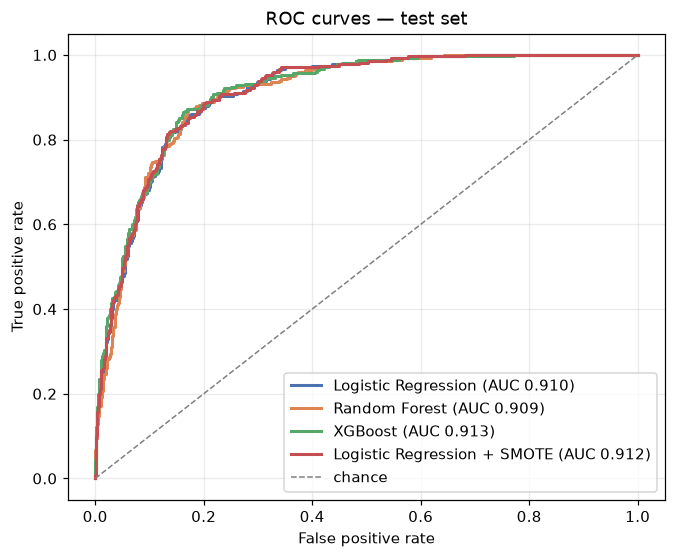

saved: reports/figures/pr_curves.png


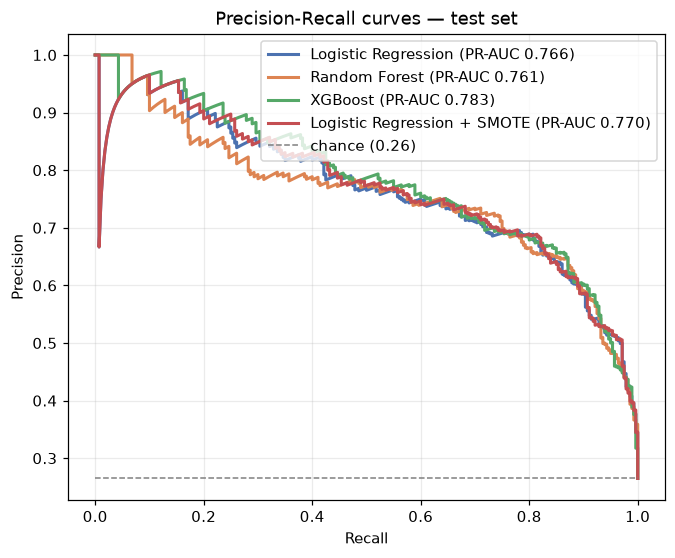

saved: reports/figures/confusion_matrices.png


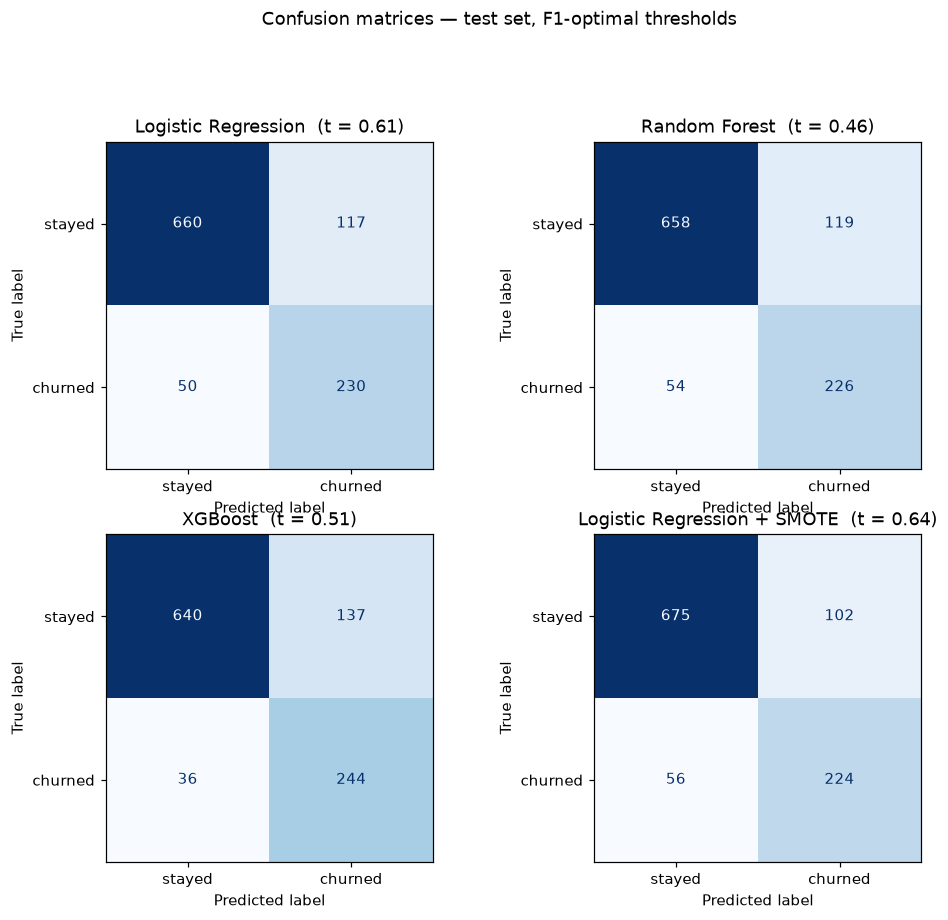

saved: reports/figures/calibration_curves.png


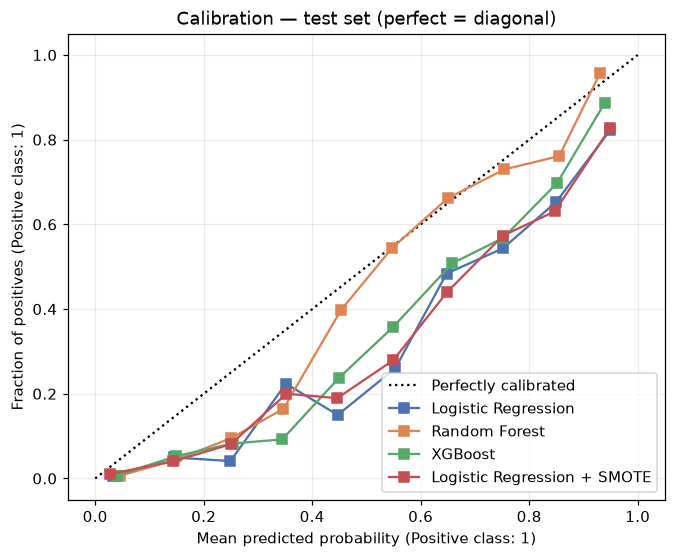

In [21]:
# ---------- Comparison figures: ROC, PR, confusion matrices, calibration ----------
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.calibration import CalibrationDisplay

colors = sns.color_palette("deep", n_colors=len(test_probas))

# ROC curves
fig, ax = plt.subplots(figsize=(7, 5.5))
for (name, proba), c in zip(test_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=c, lw=2,
            label=f"{name} (AUC {roc_auc_score(y_test, proba):.3f})")
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1, label="chance")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — test set"); ax.legend(loc="lower right")
save_fig(fig, "roc_curves")

# Precision-Recall curves
fig, ax = plt.subplots(figsize=(7, 5.5))
for (name, proba), c in zip(test_probas.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax.plot(rec, prec, color=c, lw=2,
            label=f"{name} (PR-AUC {average_precision_score(y_test, proba):.3f})")
baseline = y_test.mean()
ax.hlines(baseline, 0, 1, linestyles="--", colors="grey", lw=1,
          label=f"chance ({baseline:.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves — test set"); ax.legend(loc="upper right")
save_fig(fig, "pr_curves")

# Confusion matrices at each model's F1-optimal threshold
fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.5))
for ax, row in zip(axes.ravel(), test_rows):
    cm = row["confusion_matrix"]
    mat = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])
    ConfusionMatrixDisplay(mat, display_labels=["stayed", "churned"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{row['model']}  (t = {row['threshold']:.2f})")
    ax.grid(False)
fig.suptitle("Confusion matrices — test set, F1-optimal thresholds", y=1.02)
save_fig(fig, "confusion_matrices")

# Calibration curves
fig, ax = plt.subplots(figsize=(7, 5.5))
for (name, proba), c in zip(test_probas.items(), colors):
    CalibrationDisplay.from_predictions(
        y_test, proba, n_bins=10, ax=ax, name=name, color=c)
ax.set_title("Calibration — test set (perfect = diagonal)")
save_fig(fig, "calibration_curves")

In [22]:
# ---------- Reality checks: shuffled labels + too-good-to-be-true guard ----------
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

# 1) Shuffled-label check: same pipeline, labels randomly permuted -> AUC must collapse to ~0.5
rng = np.random.default_rng(SEED)
y_shuffled = rng.permutation(y_train.to_numpy())

check_name = test_df["roc_auc"].idxmax()
check_pipe = clone(searches[check_name].best_estimator_)
shuffle_scores = cross_val_score(check_pipe, X_train, y_shuffled, cv=3,
                                 scoring="roc_auc", n_jobs=-1)
print(f"Shuffled-label check ({check_name}, 3-fold): "
      f"ROC-AUC = {shuffle_scores.mean():.3f} +- {shuffle_scores.std():.3f}")
if shuffle_scores.mean() > 0.60:
    print("WARNING: AUC above 0.5 on shuffled labels - look for leakage!")
else:
    print("OK: performance is driven by real signal, not label leakage.")

RUN_METRICS["shuffled_label_check"] = {
    "model": check_name,
    "mean_auc": round(float(shuffle_scores.mean()), 4),
    "std": round(float(shuffle_scores.std()), 4),
}

# 2) Any metric above 0.95 -> too good to be true for this problem
flat = []
for r in RUN_METRICS["test_evaluation"]:
    flat += [r["roc_auc"], r["pr_auc"], r["accuracy"],
             r["precision"], r["recall"], r["f1"]]
flat += [RUN_METRICS["sanity_gate"]["full_feature_xgb_test_roc_auc"],
         RUN_METRICS["sanity_gate"]["base_only_xgb_test_roc_auc"]]

max_metric = max(flat)
print(f"\nHighest metric across the whole run: {max_metric:.3f}")
if max_metric > 0.95:
    print("WARNING: a metric exceeds 0.95 - results are almost certainly leaking! "
          "Re-check the feature generator and dropped columns.")
else:
    print("OK: no metric above 0.95 - realistic performance range.")

RUN_METRICS["max_metric_check"] = round(float(max_metric), 4)

Shuffled-label check (XGBoost, 3-fold): ROC-AUC = 0.501 +- 0.015
OK: performance is driven by real signal, not label leakage.

Highest metric across the whole run: 0.913
OK: no metric above 0.95 - realistic performance range.


### Final model selection + persistence

Selection criterion: **validation ROC-AUC** (tuning used training CV only, so the
validation set is an honest second opinion). The winning pipeline — preprocessing included
— is saved with `joblib` so it can be reloaded and used on raw rows exactly as produced
here.

In [23]:
import joblib

val_aucs = {name: float(roc_auc_score(y_val, p)) for name, p in val_probas.items()}
best_model_name = max(val_aucs, key=val_aucs.get)
final_pipeline = searches[best_model_name].best_estimator_

best_thr_row = next(r for r in threshold_rows if r["model"] == best_model_name)
chosen_threshold = best_thr_row["f1_optimal_threshold"]      # business operating point
cost_threshold = best_thr_row["cost_optimal_threshold"]

print("Validation ROC-AUC by model:")
for k, v in sorted(val_aucs.items(), key=lambda kv: -kv[1]):
    marker = "  <-- selected" if k == best_model_name else ""
    print(f"  {k:32s} {v:.4f}{marker}")
print(f"\nChosen threshold (F1-optimal on validation): {chosen_threshold:.3f}")
print(f"Cost-based threshold (FN = 5x FP):           {cost_threshold:.3f}")

joblib.dump(final_pipeline, "models/churn_model.joblib")
print("saved: models/churn_model.joblib")

metadata = {
    "model_name": best_model_name,
    "selection_metric": "validation ROC-AUC",
    "selection_scores": {k: round(v, 4) for k, v in val_aucs.items()},
    "best_params": {k: (v if isinstance(v, (int, float, str, type(None))) else str(v))
                    for k, v in searches[best_model_name].best_params_.items()},
    "features": X.columns.tolist(),
    "threshold_f1_optimal": round(chosen_threshold, 4),
    "threshold_cost_optimal": round(cost_threshold, 4),
    "cost_model": {"missed_churner_fn": 5, "wasted_outreach_fp": 1},
    "train_date_utc": datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "seed": SEED,
    "library_versions": {
        pkg: importlib.metadata.version(pkg)
        for pkg in ["pandas", "numpy", "scikit-learn", "imbalanced-learn",
                    "xgboost", "shap", "matplotlib", "seaborn", "joblib"]
    },
    "split_sizes": {
        "train": int(len(y_train)),
        "validation": int(len(y_val)),
        "test": int(len(y_test)),
    },
}
with open("models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("saved: models/model_metadata.json")

RUN_METRICS["final_model"] = {
    "model_name": best_model_name,
    "validation_roc_auc": round(val_aucs[best_model_name], 4),
    "threshold_f1_optimal": round(chosen_threshold, 4),
    "threshold_cost_optimal": round(cost_threshold, 4),
}

Validation ROC-AUC by model:
  XGBoost                          0.8880  <-- selected
  Logistic Regression + SMOTE      0.8845
  Logistic Regression              0.8842
  Random Forest                    0.8841

Chosen threshold (F1-optimal on validation): 0.511
Cost-based threshold (FN = 5x FP):           0.240
saved: models/churn_model.joblib
saved: models/model_metadata.json


### Noise-floor pruning (grouped, validation-based)

Permuting single columns is misleading when features move together (e.g. all engagement
metrics track the same latent signal). The pruning decision therefore uses **grouped**
importance, computed on the validation set:

1. **Grouped permutation importance** (20 repeats, scoring ROC-AUC) over four behavioural
   groups — content quality, compliance, engagement, support — plus the two noise controls
   as single-feature groups.
2. **Drop-column importance** for each group (refit without the group, validation AUC
   drop). A group only counts as important if *both* views agree.
3. **Noise floor** = the max grouped importance of `noise_control_1/2`. Any group whose
   importance is **at or below the floor in both views** is dropped as a whole group.
4. The reduced model (stronger regularisation, early stopping used **only** to select the
   number of trees) replaces the original if validation ROC-AUC drops by no more than
   **0.005**. The deployed pipeline is a plain sklearn `Pipeline` (preprocessor + XGBoost,
   no SMOTE, no early stopping in the constructor) so that clone-and-fit callers such as
   `cross_val_predict` keep working.

In [24]:
# ---------- Noise-floor pruning: grouped importance vs noise controls ----------
import shap
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Correlated features are judged in GROUPS (permuting one column of a correlated
# block understates its importance; groups are also what we can act on as a unit).
FEATURE_GROUPS = {
    "content_quality": [
        "Content_Quality_Score", "Content_Score_Trend_30D",
        "Guideline_Compliance_Score", "Search_Visibility_Change", "Traffic_Change",
    ],
    "compliance": [
        "Compliance_Flags", "Critical_Compliance_Issues",
    ],
    "engagement": [
        "Engagement_Score", "Monthly_Engagements", "Client_Meetings", "Report_Views",
        "Response_Rate", "Days_Since_Last_Engagement",
    ],
    "support": [
        "Support_Tickets", "Unresolved_Support_Tickets", "Avg_Resolution_Time",
    ],
}
NOISE_CONTROLS_RAW = ["noise_control_1", "noise_control_2"]
features_before_count = int(X.shape[1])  # recorded before any reassignment below
orig_pipeline = final_pipeline

# ---- Grouped permutation importance on the validation set (n_repeats = 20) ----
rng_g = np.random.default_rng(SEED)
groups = {**FEATURE_GROUPS, **{c: [c] for c in NOISE_CONTROLS_RAW if c in X.columns}}
Xv = X_val.reset_index(drop=True).copy()
yv = y_val.reset_index(drop=True).to_numpy()
base_auc_val = float(roc_auc_score(yv, orig_pipeline.predict_proba(Xv)[:, 1]))

perm_means = {}
for gname, cols in groups.items():
    cols = [c for c in cols if c in Xv.columns]
    drops = []
    for _ in range(20):
        Xp = Xv.copy()
        idx = rng_g.permutation(len(Xp))
        Xp[cols] = Xp[cols].to_numpy()[idx]
        drops.append(base_auc_val - float(
            roc_auc_score(yv, orig_pipeline.predict_proba(Xp)[:, 1])))
    perm_means[gname] = float(np.mean(drops))

# ---- Drop-group importance on the validation set ----
# A cloned pipeline cannot be refit on a reduced frame: its ColumnTransformer still
# lists the dropped columns and fit raises "column is not a column of the dataframe".
# So each reduced model rebuilds its own preprocessor and reuses the selected model's
# hyperparameters (same recipe, one column block removed).
def _fit_without_cols(cols_to_drop):
    cols_less = [c for c in X.columns if c not in set(cols_to_drop)]
    num_less = [c for c in numerical_cols if c in cols_less]
    cat_less = [c for c in categorical_cols if c in cols_less]
    pre_less = ColumnTransformer([
        ("num", SkPipeline([("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler())]), num_less),
        ("cat", SkPipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first",
                                                     sparse_output=False))]), cat_less),
    ])
    Xtr_less = pre_less.fit_transform(X_train[cols_less])
    model_less = clone(final_pipeline.named_steps["model"])
    model_less.fit(Xtr_less, y_train)
    Xv_less = pre_less.transform(Xv[cols_less])
    return float(roc_auc_score(yv, model_less.predict_proba(Xv_less)[:, 1]))

dropcol_means = {}
for gname, cols in groups.items():
    dropcol_means[gname] = base_auc_val - _fit_without_cols(
        [c for c in cols if c in Xv.columns])

importance_df = pd.DataFrame({
    "group_perm_importance": pd.Series(perm_means).round(5),
    "group_dropcol_importance": pd.Series(dropcol_means).round(5),
}).sort_values("group_perm_importance", ascending=False)
display(importance_df)

noise_floor = float(max(perm_means[c] for c in NOISE_CONTROLS_RAW))
print(f"\nBase validation ROC-AUC: {base_auc_val:.4f} | "
      f"noise floor (max control importance): {noise_floor:.5f}")

# ---- Drop only whole groups that sit at/below the noise floor in BOTH views ----
groups_to_drop, groups_to_keep = [], []
for gname in FEATURE_GROUPS:
    if gname not in perm_means:
        continue
    below_floor = (perm_means[gname] <= noise_floor) and (dropcol_means[gname] <= noise_floor)
    (groups_to_drop if below_floor else groups_to_keep).append(gname)
kept_features = [c for c in X.columns
                 if c not in NOISE_CONTROLS_RAW
                 and not any(c in groups[g] for g in groups_to_drop)]
dropped_features = [c for c in X.columns if c not in kept_features]
print("Groups kept  :", groups_to_keep)
print("Groups dropped:", groups_to_drop)
print(f"Features: {features_before_count} -> {len(kept_features)} "
      f"(dropped: {dropped_features})")

# ---- Retrain reduced model: stronger regularisation; early stopping ONLY for selection ----
num_k = [c for c in numerical_cols if c in kept_features]
cat_k = [c for c in categorical_cols if c in kept_features]
pre_k = ColumnTransformer([
    ("num", SkPipeline([("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())]), num_k),
    ("cat", SkPipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first",
                                                 sparse_output=False))]), cat_k),
])
Xtr_k = pre_k.fit_transform(X_train[kept_features])
Xva_k = pre_k.transform(X_val[kept_features])

rng_prune = np.random.default_rng(SEED)
prune_grid = [
    {"max_depth": int(d), "min_child_weight": int(m), "reg_lambda": float(l)}
    for d, m, l in zip(
        rng_prune.choice([2, 3, 4], size=12),
        rng_prune.choice([5, 10, 20], size=12),
        rng_prune.choice([5, 10, 20], size=12),
    )
]
best_prune_auc, best_prune_params, best_iter = -1.0, None, None
for g in prune_grid:
    m_ = XGBClassifier(
        n_estimators=600, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=spw, tree_method="hist", n_jobs=1, random_state=SEED,
        eval_metric="logloss", early_stopping_rounds=30, **g,
    )
    m_.fit(Xtr_k, y_train, eval_set=[(Xva_k, y_val)], verbose=False)
    auc_ = roc_auc_score(y_val, m_.predict_proba(Xva_k)[:, 1])
    if auc_ > best_prune_auc:
        best_prune_auc, best_prune_params, best_iter = auc_, g, int(m_.best_iteration)
print(f"Best reduced-model validation ROC-AUC: {best_prune_auc:.4f} {best_prune_params} "
      f"| best iteration: {best_iter}")

# ---- Before/after test metrics (sanctioned second test pass for this report) ----
before_row = next(r for r in RUN_METRICS["test_evaluation"] if r["model"] == best_model_name)
m_before = before_row

def _reduced_test_metrics(params, n_est):
    m_ = XGBClassifier(
        n_estimators=n_est, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=spw, tree_method="hist", n_jobs=1, random_state=SEED,
        eval_metric="logloss", **params,
    )
    m_.fit(Xtr_k, y_train)
    p_ = m_.predict_proba(pre_k.transform(X_test[kept_features]))[:, 1]
    return (float(roc_auc_score(y_test, p_)),
            float(average_precision_score(y_test, p_)))

test_auc_after, test_pr_after = _reduced_test_metrics(best_prune_params, best_iter)
print(f"\nTest BEFORE pruning: ROC-AUC {m_before['roc_auc']:.4f} | "
      f"PR-AUC {m_before['pr_auc']:.4f} | features {features_before_count}")
print(f"Test AFTER  pruning: ROC-AUC {test_auc_after:.4f} | "
      f"PR-AUC {test_pr_after:.4f} | features {len(kept_features)}")

# ---- Decision: keep the pruned model only if validation ROC-AUC drops <= 0.005 ----
orig_val_auc = val_aucs[best_model_name]
pruning_applied = bool(best_model_name == "XGBoost"
                       and best_prune_auc >= orig_val_auc - 0.005)
if best_model_name != "XGBoost":
    print(f"NOTE: selected model is {best_model_name}; the reduced retrain is XGBoost, "
          "so pruning is reported but NOT deployed (model-identity guard).")

if pruning_applied:
    # Deploy a PLAIN sklearn Pipeline: preprocessor + XGBoost. No SMOTE, and no
    # early stopping in the constructor (clones inside cross_val_predict never
    # receive eval_set). Early stopping above only chose params and n_estimators.
    prod_model = XGBClassifier(
        n_estimators=max(1, best_iter),
        learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=spw, tree_method="hist", n_jobs=1, random_state=SEED,
        eval_metric="logloss", **best_prune_params,
    )
    X = X[kept_features]
    X_train, X_val, X_test = (
        X_train[kept_features], X_val[kept_features], X_test[kept_features])
    final_pipeline = SkPipeline([
        ("preprocessor", pre_k),
        ("model", prod_model),
    ])
    final_pipeline.fit(X_train, y_train)
    print("\nDeployed pipeline.named_steps:", list(final_pipeline.named_steps.keys()))
    print(final_pipeline)
    assert isinstance(final_pipeline, SkPipeline)
    assert "sampler" not in final_pipeline.named_steps
    assert all(getattr(s, "early_stopping_rounds", None) is None
                   for s in final_pipeline.named_steps.values())

    # Re-choose thresholds for the deployed model on validation
    val_proba_pruned = final_pipeline.predict_proba(X_val)[:, 1]
    chosen_threshold = best_threshold_by_f1(y_val.to_numpy(), val_proba_pruned)
    cost_threshold, _ = best_threshold_by_cost(
        y_val.to_numpy(), val_proba_pruned, fn_cost=5.0, fp_cost=1.0)

    test_proba_deploy = final_pipeline.predict_proba(X_test)[:, 1]
    prune_extra = {
        "test_after_full": metrics_at_threshold(y_test, test_proba_deploy, chosen_threshold),
        "test_after_cost": metrics_at_threshold(y_test, test_proba_deploy, cost_threshold),
    }
    RUN_METRICS["max_metric_check"] = round(
        max(RUN_METRICS["max_metric_check"],
            prune_extra["test_after_full"]["roc_auc"],
            prune_extra["test_after_full"]["pr_auc"]), 4)

    metadata["features"] = kept_features
    metadata["feature_groups"] = {k: [c for c in v if c in kept_features]
                                  for k, v in FEATURE_GROUPS.items()}
    metadata["variant"] = "group-noise-pruned"
    metadata["pruned_groups"] = groups_to_drop
    metadata["surviving_groups"] = groups_to_keep
    metadata["pruned_features"] = dropped_features
    metadata["prune_best_params"] = best_prune_params
    metadata["prune_early_stopping_best_iter"] = best_iter
    metadata["threshold_f1_optimal"] = round(chosen_threshold, 4)
    metadata["threshold_cost_optimal"] = round(cost_threshold, 4)
    joblib.dump(final_pipeline, "models/churn_model.joblib")
    with open("models/model_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)
    RUN_METRICS["final_model"].update({
        "validation_roc_auc": round(best_prune_auc, 4),
        "variant": "group-noise-pruned",
        "threshold_f1_optimal": round(chosen_threshold, 4),
        "threshold_cost_optimal": round(cost_threshold, 4),
    })
    print(f"Re-chosen thresholds on validation: F1-optimal {chosen_threshold:.3f} | "
          f"cost-based {cost_threshold:.3f}")
    print("DECISION: PRUNED MODEL KEPT "
          f"(validation ROC-AUC {best_prune_auc:.4f} vs original {orig_val_auc:.4f}; "
          "drop within the 0.005 tolerance). Saved pipeline, metadata and feature matrix "
          "updated.")
else:
    print("\nDECISION: ORIGINAL MODEL KEPT "
          f"(reduced model validation ROC-AUC {best_prune_auc:.4f} lost more than 0.005 "
          f"vs {orig_val_auc:.4f}, or selected model is not XGBoost). "
          "The saved pipeline is unchanged.")
    _t_row = next(r for r in threshold_rows if r["model"] == best_model_name)
    prune_extra = {
        "test_after_full": metrics_at_threshold(
            y_test, orig_pipeline.predict_proba(X_test)[:, 1],
            _t_row["f1_optimal_threshold"]),
        "test_after_cost": metrics_at_threshold(
            y_test, orig_pipeline.predict_proba(X_test)[:, 1],
            _t_row["cost_optimal_threshold"]),
    }

RUN_METRICS["noise_floor_pruning"] = {
    "applied": pruning_applied,
    "method": "grouped permutation + drop-group importance (validation)",
    "noise_floor": round(noise_floor, 5),
    "n_repeats": 20,
    "group_importance": {g: {"perm": round(perm_means[g], 5),
                             "dropcol": round(dropcol_means[g], 5)}
                         for g in perm_means},
    "groups_kept": groups_to_keep,
    "groups_dropped": groups_to_drop,
    "features_before": features_before_count,
    "features_after": len(kept_features) if pruning_applied else features_before_count,
    "dropped_features": dropped_features if pruning_applied else [],
    "val_auc_before": round(orig_val_auc, 4),
    "val_auc_after": round(best_prune_auc, 4),
    "test_before": {"roc_auc": m_before["roc_auc"], "pr_auc": m_before["pr_auc"]},
    "test_after": {"roc_auc": round(test_auc_after, 4), "pr_auc": round(test_pr_after, 4)},
    "prune_best_params": best_prune_params,
    **(prune_extra if pruning_applied else prune_extra),
}

,group_perm_importance,group_dropcol_importance
engagement,0.05690,0.01578
content_quality,0.01105,0.00053
compliance,0.00836,0.00314
support,0.00454,0.00157
noise_control_2,0.00012,-0.00039
noise_control_1,0.00011,-0.00038



Base validation ROC-AUC: 0.8880 | noise floor (max control importance): 0.00012
Groups kept  : ['content_quality', 'compliance', 'engagement', 'support']
Groups dropped: []
Features: 24 -> 22 (dropped: ['noise_control_1', 'noise_control_2'])


Best reduced-model validation ROC-AUC: 0.8913 {'max_depth': 2, 'min_child_weight': 10, 'reg_lambda': 10.0} | best iteration: 408

Test BEFORE pruning: ROC-AUC 0.9131 | PR-AUC 0.7834 | features 24
Test AFTER  pruning: ROC-AUC 0.9147 | PR-AUC 0.7857 | features 22



Deployed pipeline.named_steps: ['preprocessor', 'model']
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Client_Tenure_Months',
                                                   'Monthly_Client_Value',
                                                   'Cumulative_Client_Value',
                                                   'Content_Quality_Score',
                                                   'Content_Score_Trend_30D',
                                                   'Guideline_Compliance_Score',
                                            

## Part 4 — Why clients churn: SHAP explanations

We explain the **selected** model on the test set. Tree models use `TreeExplainer`; if the
winner were a linear model we would fall back to `LinearExplainer`. Global importance,
direction of effect, and three individual client explanations are shown below.

In [25]:
import shap
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

# Transform features exactly as the pipeline does
pre = final_pipeline.named_steps["preprocessor"]
feature_names = pre.get_feature_names_out()
X_test_t = pd.DataFrame(
    pre.transform(X_test), columns=feature_names, index=X_test.index)
X_train_t = pd.DataFrame(
    pre.transform(X_train), columns=feature_names, index=X_train.index)

best_step_model = final_pipeline.named_steps["model"]
if isinstance(best_step_model, (xgb.XGBClassifier, RandomForestClassifier)):
    explainer = shap.TreeExplainer(best_step_model)
else:
    explainer = shap.LinearExplainer(best_step_model, X_train_t)

# Modern explainer API returns a ready-to-plot Explanation (feature names, base value)
try:
    shap_exp = explainer(X_test_t)
except Exception:
    # Fallback: build the Explanation manually (base_values must be per-row)
    sv = explainer.shap_values(X_test_t)
    if isinstance(sv, list):  # older shap returns [class0, class1]
        sv = sv[1]
    shap_exp = shap.Explanation(
        values=sv,
        base_values=np.full(len(X_test_t), float(np.ravel(explainer.expected_value)[0])),
        data=X_test_t.values,
        feature_names=list(feature_names),
    )

shap_values = shap_exp.values
print("SHAP matrix:", shap_values.shape, "| base value (log-odds):",
      round(float(np.mean(shap_exp.base_values)), 4))

SHAP matrix: (1057, 25) | base value (log-odds): 0.0183


saved: reports/figures/shap_summary_bar.png


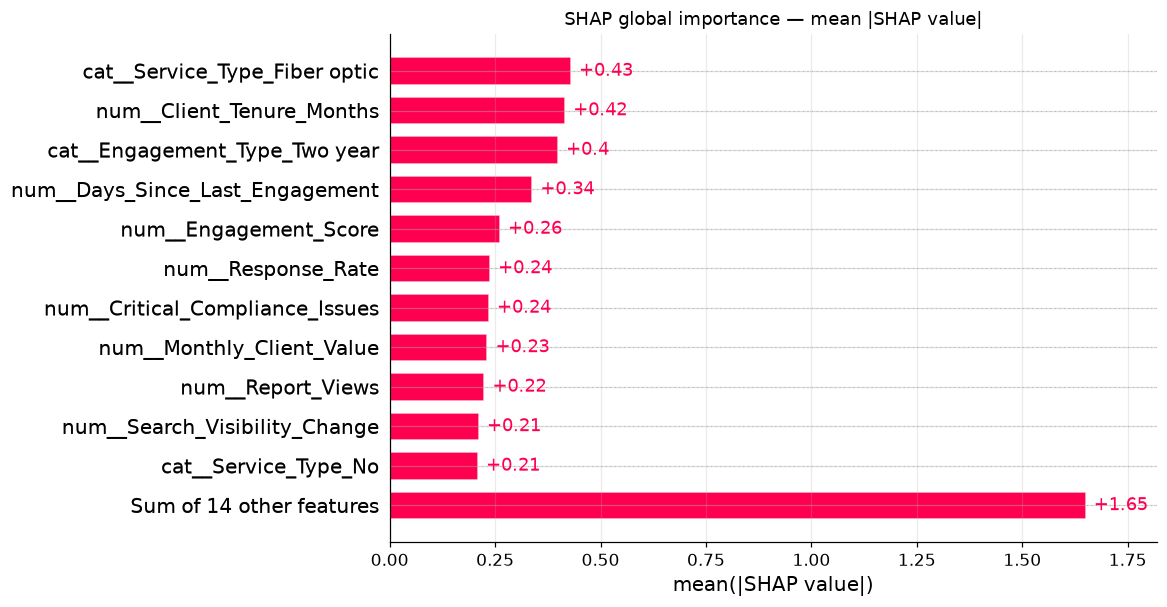

saved: reports/figures/shap_beeswarm.png


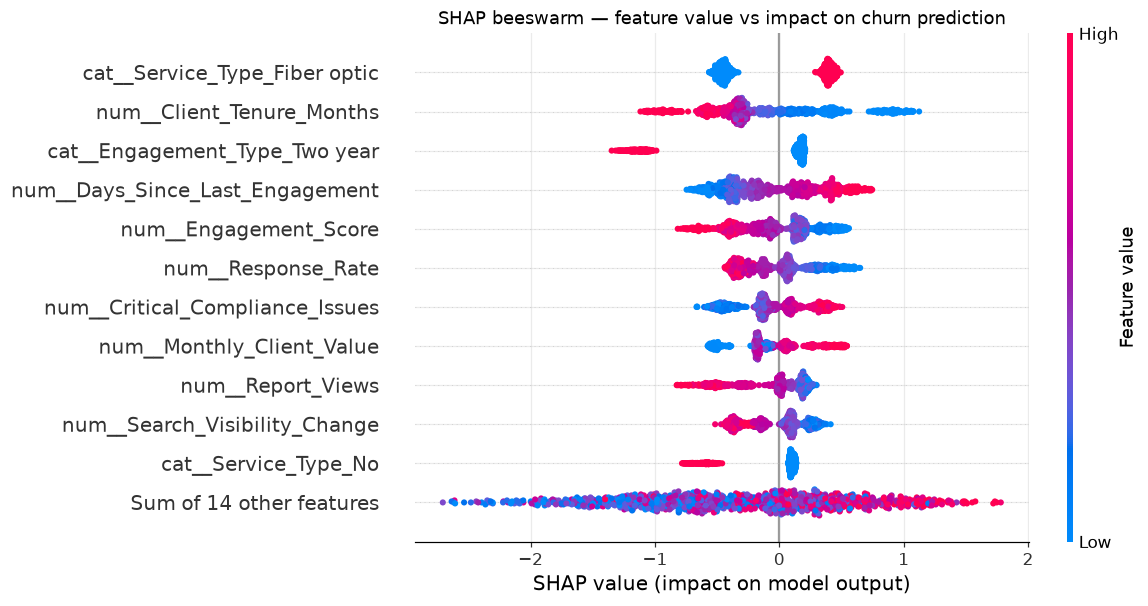

In [26]:
# Global importance + direction of effect
shap.plots.bar(shap_exp, max_display=12, show=False)
plt.gcf().set_size_inches(9, 6)
plt.title("SHAP global importance — mean |SHAP value|")
save_fig(plt.gcf(), "shap_summary_bar")

shap.plots.beeswarm(shap_exp, max_display=12, show=False)
plt.gcf().set_size_inches(9, 6)
plt.title("SHAP beeswarm — feature value vs impact on churn prediction")
save_fig(plt.gcf(), "shap_beeswarm")

In [27]:
# Top 10 drivers with a plain-English meaning
BASE_MEANINGS = {
    "Client_Tenure_Months": "how long the client has stayed with us",
    "Monthly_Client_Value": "the client's monthly spend",
    "Cumulative_Client_Value": "total revenue billed to date",
    "Content_Quality_Score": "audit score for delivered content quality",
    "Content_Score_Trend_30D": "whether content scores are improving or slipping (30-day change)",
    "Guideline_Compliance_Score": "how well client content follows search guidelines",
    "Compliance_Flags": "number of open guideline compliance flags",
    "Critical_Compliance_Issues": "count of critical compliance issues",
    "Engagement_Score": "overall engagement with our advisory service",
    "Monthly_Engagements": "advisory touchpoints per month",
    "Client_Meetings": "client meetings per month",
    "Report_Views": "how often the client opens performance reports",
    "Response_Rate": "how quickly the client responds to outreach",
    "Support_Tickets": "support tickets raised",
    "Unresolved_Support_Tickets": "support tickets still unresolved",
    "Avg_Resolution_Time": "average days to resolve a ticket",
    "Days_Since_Last_Engagement": "days since the client last engaged with us",
    "Search_Visibility_Change": "30-day change in the client's search visibility",
    "Traffic_Change": "30-day change in the client's search traffic",
    "noise_control_1": "pure-noise feature (control)",
    "noise_control_2": "pure-noise feature (control)",
}

def plain_english(feature_name):
    # Translate a transformed feature name into a business-friendly phrase
    if feature_name.startswith("num__"):
        return BASE_MEANINGS.get(feature_name[5:], feature_name)
    if feature_name.startswith("cat__"):
        rest = feature_name[5:]
        for col in categorical_cols:
            if rest.startswith(col + "_"):
                return f"{col.replace('_', ' ')} = '{rest[len(col) + 1:]}'"
    return feature_name

mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs)[::-1]

top10_rows = []
for idx in order[:10]:
    fname = feature_names[idx]
    corr = np.corrcoef(shap_values[:, idx], X_test_t.iloc[:, idx])[0, 1]
    if np.isnan(corr):
        direction = "direction n/a (constant feature)"
    elif corr > 0:
        direction = "higher value -> higher churn risk"
    else:
        direction = "higher value -> lower churn risk"
    top10_rows.append({
        "rank": len(top10_rows) + 1,
        "feature": fname,
        "mean_abs_shap": round(float(mean_abs[idx]), 4),
        "meaning": plain_english(fname),
        "direction": direction,
    })

top10_df = pd.DataFrame(top10_rows).set_index("rank")
display(top10_df)
RUN_METRICS["shap_top10_drivers"] = top10_rows

,feature,mean_abs_shap,meaning,direction
rank,,,,
1,cat__Service_Type_Fiber optic,0.4295,Service Type = 'Fiber optic',higher value -> higher churn risk
2,num__Client_Tenure_Months,0.4158,how long the client has stayed with us,higher value -> lower churn risk
3,cat__Engagement_Type_Two year,0.3989,Engagement Type = 'Two year',higher value -> lower churn risk
4,num__Days_Since_Last_Engagement,0.3379,days since the client last engaged with us,higher value -> higher churn risk
5,num__Engagement_Score,0.2612,overall engagement with our advisory service,higher value -> lower churn risk
6,num__Response_Rate,0.2377,how quickly the client responds to outreach,higher value -> lower churn risk
7,num__Critical_Compliance_Issues,0.2351,count of critical compliance issues,higher value -> higher churn risk
8,num__Monthly_Client_Value,0.2315,the client's monthly spend,higher value -> higher churn risk
9,num__Report_Views,0.2243,how often the client opens performance reports,higher value -> lower churn risk


In [28]:
# ---------- Pure-noise control check: where do the controls rank? ----------
NOISE_CONTROLS_T = ["num__noise_control_1", "num__noise_control_2"]
pruning_applied = RUN_METRICS.get("noise_floor_pruning", {}).get("applied", False)

rank_of = {feature_names[i]: int(pos) + 1 for pos, i in enumerate(order)}
noise_ranks = {}
for fname in NOISE_CONTROLS_T:
    if fname in feature_names:
        rk = rank_of.get(fname)
        noise_ranks[fname] = rk
        print(f"{fname}  ->  SHAP rank {rk} of {len(feature_names)}  ({plain_english(fname)})")
        if rk <= 10:
            print(f"WARNING: pure-noise control '{fname}' ranks in the top 10 - the model "
                  "is fitting generator noise; consider stronger regularisation.")
    else:
        noise_ranks[fname] = None
        print(f"{fname}  ->  not in the final model "
              f"({'dropped by noise-floor pruning - as intended' if pruning_applied else 'missing!'})")

RUN_METRICS["noise_feature_check"] = {
    "ranks": noise_ranks,
    "n_features": int(len(feature_names)),
    "any_in_top10": bool(any(r is not None and r <= 10 for r in noise_ranks.values())),
    "pruned_from_model": pruning_applied,
}

num__noise_control_1  ->  not in the final model (dropped by noise-floor pruning - as intended)
num__noise_control_2  ->  not in the final model (dropped by noise-floor pruning - as intended)


saved: reports/figures/shap_local_high_risk.png


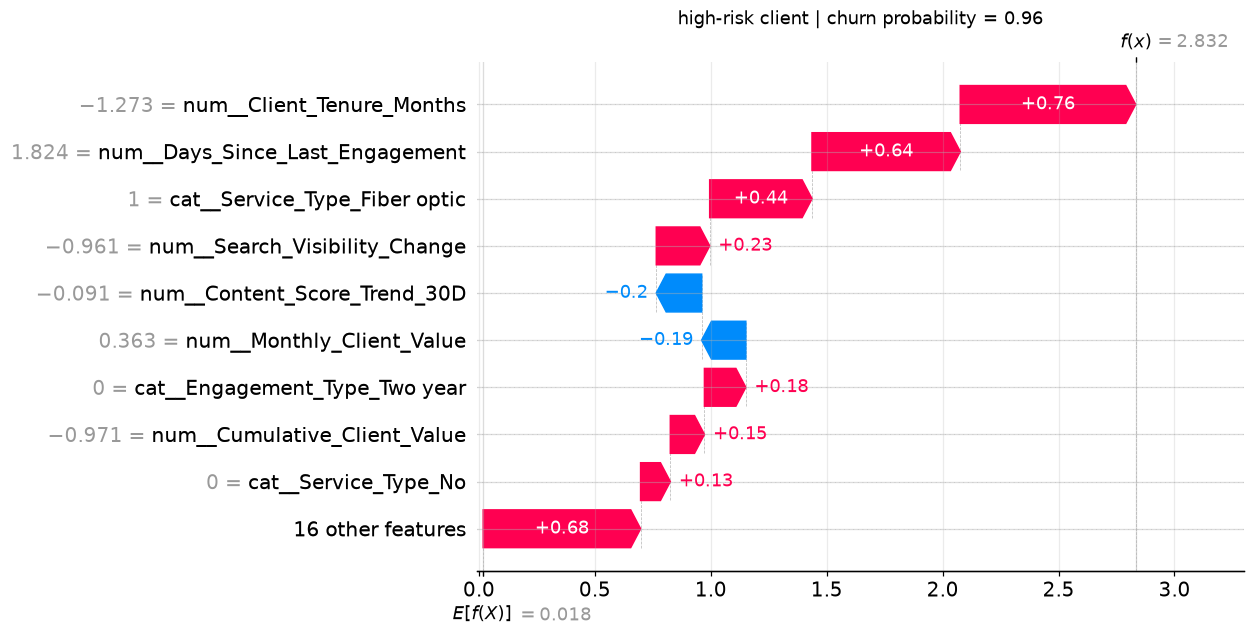

saved: reports/figures/shap_local_medium_risk.png


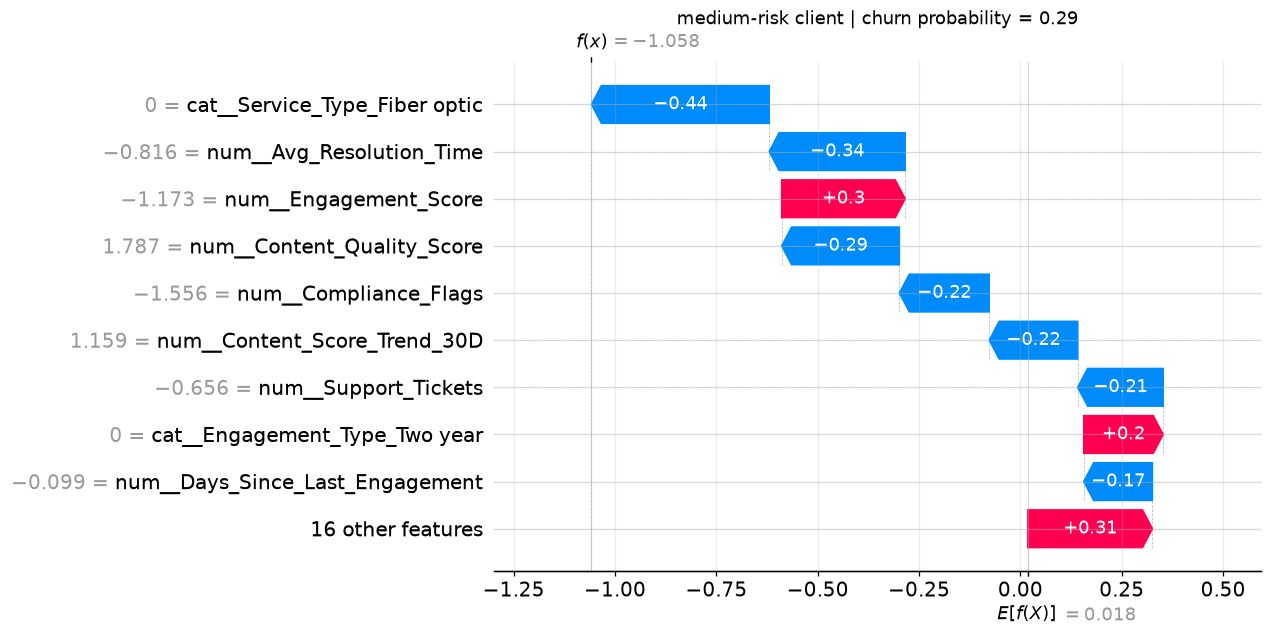

saved: reports/figures/shap_local_low_risk.png


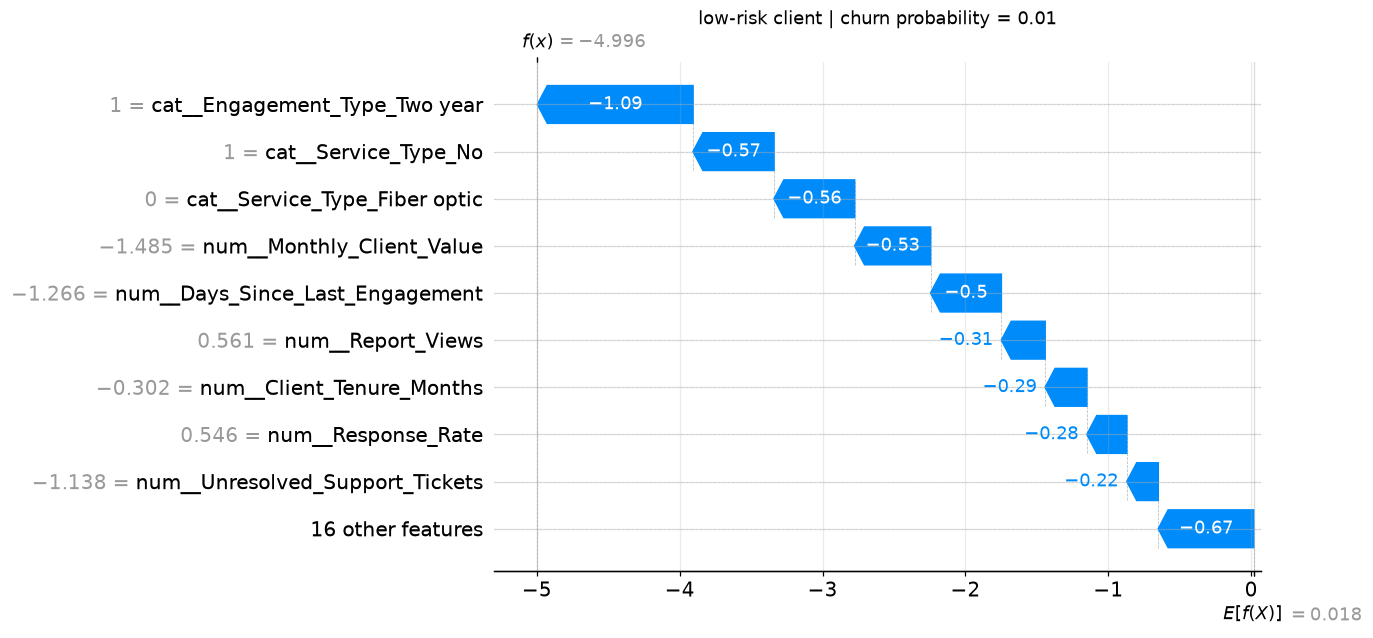

In [29]:
# Three individual client explanations: high / medium / low predicted risk
test_proba_best = test_probas[best_model_name]
risk_order = np.argsort(test_proba_best)
picks = {
    "high": int(risk_order[int(len(risk_order) * 0.98)]),   # ~98th percentile
    "medium": int(risk_order[len(risk_order) // 2]),        # median
    "low": int(risk_order[max(0, len(risk_order) // 20)]),  # ~5th percentile
}

for level, i in picks.items():
    shap.plots.waterfall(shap_exp[i], max_display=10, show=False)
    plt.gcf().set_size_inches(9, 6)
    plt.title(f"{level}-risk client | churn probability = {test_proba_best[i]:.2f}")
    save_fig(plt.gcf(), f"shap_local_{level}_risk")

## Part 5 — Segmentation & retention playbook (out-of-fold scores)

Every client is scored with **out-of-fold predictions**: `cross_val_predict` with 5-fold
stratified CV over the full roster, so each client's churn probability comes from a model
that never trained on that client (no in-sample optimism). Model *performance* is reported
only from the untouched test set (Part 3); the numbers here are for ranking and sizing.

- **Risk** — high if OOF churn probability ≥ the validation-chosen threshold
- **Value** — high if `Monthly_Client_Value × expected remaining months` ≥ median
  (expected remaining months = `72 − tenure`, capped at 24)
- **Expected loss** — probability-weighted exposure: `churn_probability × value`,
  summed per segment

| Segment | Action |
|---|---|
| High risk + High value | **Save now** — senior advisor call + content strategy review within 7 days |
| High risk + Low value | **Automated nudge** — email/portal tips + self-serve content check |
| Low risk + High value | **Nurture** — quarterly business review + upsell content roadmap |
| Low risk + Low value | **Monitor** — automated health score, standard support |

Advisor capacity is finite, so the operational **"Save now" queue** is a ranked list: the
top `SAVE_NOW_CAPACITY` clients by expected loss (`churn_probability × value`), regardless
of which quadrant they fall in.

In [30]:
# ---------- Out-of-fold scoring + expected-loss segmentation ----------
from sklearn.model_selection import cross_val_predict, StratifiedKFold

# 1) Out-of-fold churn probability for every client (5-fold stratified CV)
cv_seg = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_proba = cross_val_predict(
    final_pipeline, X, y, cv=cv_seg, method="predict_proba", n_jobs=-1
)[:, 1]

oof_auc = roc_auc_score(y, oof_proba)
print(f"Out-of-fold ROC-AUC across the full roster: {oof_auc:.3f}")
print("(diagnostic only - official performance metrics come from the untouched test set)")

seg_df = client_df.copy()
seg_df["churn_probability"] = pd.Series(oof_proba, index=X.index)

# 2) Value and probability-weighted expected loss
seg_df["expected_remaining_months"] = np.clip(72 - seg_df["Client_Tenure_Months"], 0, 24)
seg_df["expected_value_remaining"] = (
    seg_df["Monthly_Client_Value"] * seg_df["expected_remaining_months"]
)
value_median = float(seg_df["expected_value_remaining"].median())

seg_df["priority_score"] = (
    seg_df["churn_probability"] * seg_df["expected_value_remaining"]
)

# 3) Tiers and playbook segments
seg_df["risk_tier"] = np.where(
    seg_df["churn_probability"] >= chosen_threshold, "High risk", "Low risk")
seg_df["value_tier"] = np.where(
    seg_df["expected_value_remaining"] >= value_median, "High value", "Low value")
seg_df["segment"] = seg_df["risk_tier"] + " + " + seg_df["value_tier"]

PLAYBOOK = {
    "High risk + High value": "Save now - senior advisor call + content strategy review within 7 days",
    "High risk + Low value": "Automated nudge - email/portal tips + self-serve content check",
    "Low risk + High value": "Nurture - quarterly business review + upsell content roadmap",
    "Low risk + Low value": "Monitor - automated health score, standard support",
}
seg_df["recommended_action"] = seg_df["segment"].map(PLAYBOOK)

# 4) Segment summary with probability-weighted expected loss
summary_rows = []
for seg, grp in seg_df.groupby("segment"):
    summary_rows.append({
        "segment": seg,
        "clients": int(len(grp)),
        "share_pct": round(100 * len(grp) / len(seg_df), 1),
        "expected_loss": round(float((grp["churn_probability"]
                                      * grp["expected_value_remaining"]).sum()), 0),
        "action": PLAYBOOK[seg],
    })
summary_rows = sorted(summary_rows, key=lambda r: r["segment"])
segment_summary_df = pd.DataFrame(summary_rows).set_index("segment")
display(segment_summary_df)

total_expected_loss = float(seg_df["priority_score"].sum())
print(f"\\nThreshold used: {chosen_threshold:.3f} | value median: {value_median:,.0f}")
print(f"Total expected loss (all clients, probability-weighted): {total_expected_loss:,.0f}")

# 5) Capacity-based Save-now queue: top N by expected loss
SAVE_NOW_CAPACITY = 50  # advisor capacity per cycle - configurable

save_now_df = (seg_df.sort_values("priority_score", ascending=False)
               .head(SAVE_NOW_CAPACITY)
               .loc[:, ["Client_ID", "churn_probability", "expected_value_remaining",
                        "priority_score", "segment", "recommended_action"]])

covered = float(save_now_df["priority_score"].sum())
print(f"\\nSave-now queue (top {SAVE_NOW_CAPACITY} by churn_probability x value) - "
      f"first 10 shown:")
display(save_now_df.head(10))
print(f"These {SAVE_NOW_CAPACITY} calls cover {covered:,.0f} of expected loss "
      f"= {100 * covered / total_expected_loss:.1f}% of the total.")

save_now_df.to_csv("reports/save_now_list.csv", index=False)
print("saved: reports/save_now_list.csv")

seg_df[["Client_ID", "churn_probability", "expected_value_remaining", "priority_score",
        "risk_tier", "value_tier", "segment", "recommended_action"]].to_csv(
    "reports/segments.csv", index=False)
print("saved: reports/segments.csv")

RUN_METRICS["segmentation"] = {
    "scoring": "out-of-fold cross_val_predict, 5-fold stratified",
    "oof_roc_auc_diagnostic": round(float(oof_auc), 4),
    "threshold_used": round(chosen_threshold, 4),
    "value_median": round(value_median, 2),
    "segments": summary_rows,
    "total_expected_loss": round(total_expected_loss, 0),
    "save_now": {
        "capacity": SAVE_NOW_CAPACITY,
        "file": "reports/save_now_list.csv",
        "covered_expected_loss": round(covered, 0),
        "covered_share_pct": round(100 * covered / total_expected_loss, 1),
        "top10_client_ids": save_now_df.head(10)["Client_ID"].tolist(),
    },
}

Out-of-fold ROC-AUC across the full roster: 0.907
(diagnostic only - official performance metrics come from the untouched test set)


,clients,share_pct,expected_loss,action
segment,,,,
High risk + High value,1647,23.4,2729353.0,Save now - senior advisor call + content strat...
High risk + Low value,424,6.0,270231.0,Automated nudge - email/portal tips + self-ser...
Low risk + High value,1879,26.7,906244.0,Nurture - quarterly business review + upsell c...
Low risk + Low value,3093,43.9,238092.0,"Monitor - automated health score, standard sup..."


\nThreshold used: 0.609 | value median: 1,196
Total expected loss (all clients, probability-weighted): 4,143,920
\nSave-now queue (top 50 by churn_probability x value) - first 10 shown:


,Client_ID,churn_probability,expected_value_remaining,priority_score,segment,recommended_action
223,9851-KIELU,0.983026,2642.4,2597.549078,High risk + High value,Save now - senior advisor call + content strat...
305,3992-YWPKO,0.970591,2637.6,2560.031002,High risk + High value,Save now - senior advisor call + content strat...
594,1583-IHQZE,0.941172,2710.8,2551.329714,High risk + High value,Save now - senior advisor call + content strat...
2375,5760-IFJOZ,0.982130,2590.8,2544.502999,High risk + High value,Save now - senior advisor call + content strat...
204,0115-TFERT,0.947286,2668.8,2528.115789,High risk + High value,Save now - senior advisor call + content strat...
293,8111-SLLHI,0.985697,2535.6,2499.334299,High risk + High value,Save now - senior advisor call + content strat...
442,9158-VCTQB,0.910389,2726.4,2482.085561,High risk + High value,Save now - senior advisor call + content strat...
5630,6591-QGOYB,0.967618,2559.6,2476.714393,High risk + High value,Save now - senior advisor call + content strat...
1513,0363-QJVFX,0.949714,2595.6,2465.076743,High risk + High value,Save now - senior advisor call + content strat...
1044,4587-VVTOX,0.974460,2527.2,2462.654272,High risk + High value,Save now - senior advisor call + content strat...


These 50 calls cover 120,641 of expected loss = 2.9% of the total.
saved: reports/save_now_list.csv
saved: reports/segments.csv


Clients needed to cover 25% of total expected loss: N = 496
50% of total expected loss not reached within N = 1000.
75% of total expected loss not reached within N = 1000.
saved: reports/figures/capacity_curve.png


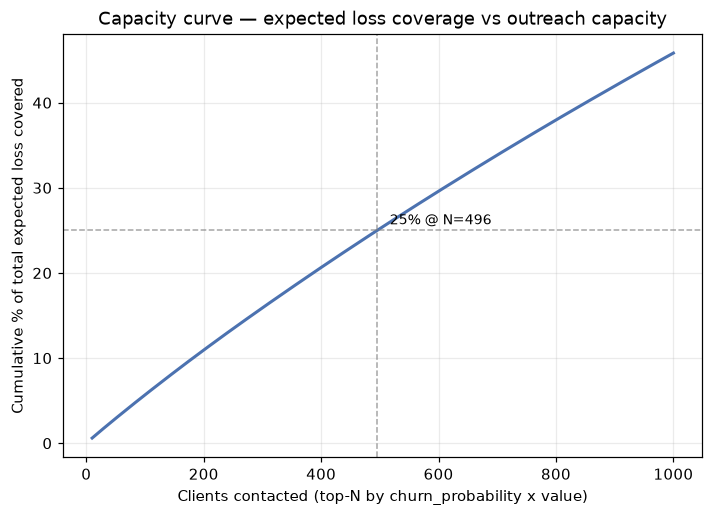

\nNote: the curve shape depends on the value distribution. In this synthetic data client value is nearly flat (re-framed telecom bills), so coverage grows almost linearly with N; with real client contract values (heavier tail) the curve would bend much earlier.


In [31]:
# ---------- Capacity curve: expected loss covered vs clients contacted ----------
ranked = seg_df.sort_values("priority_score", ascending=False).reset_index(drop=True)
cum_pct = ranked["priority_score"].cumsum() / total_expected_loss * 100

Ns = np.arange(10, 1001)
cum_at_N = cum_pct.iloc[Ns - 1].to_numpy()

targets = {}
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(Ns, cum_at_N, lw=2, color=sns.color_palette("deep")[0])
for target in [25, 50, 75]:
    hit = np.searchsorted(cum_at_N, target)
    if hit < len(Ns):
        n_needed = int(Ns[hit])
        targets[f"n_for_{target}_pct"] = n_needed
        ax.axvline(n_needed, ls="--", lw=1, color="grey", alpha=0.7)
        ax.axhline(target, ls="--", lw=1, color="grey", alpha=0.7)
        ax.annotate(f"{target}% @ N={n_needed}", (n_needed, target),
                    xytext=(8, 4), textcoords="offset points", fontsize=9)
        print(f"Clients needed to cover {target}% of total expected loss: N = {n_needed}")
    else:
        targets[f"n_for_{target}_pct"] = None
        print(f"{target}% of total expected loss not reached within N = 1000.")

ax.set_xlabel("Clients contacted (top-N by churn_probability x value)")
ax.set_ylabel("Cumulative % of total expected loss covered")
ax.set_title("Capacity curve — expected loss coverage vs outreach capacity")
save_fig(fig, "capacity_curve")

print("\\nNote: the curve shape depends on the value distribution. In this synthetic data "
      "client value is nearly flat (re-framed telecom bills), so coverage grows almost "
      "linearly with N; with real client contract values (heavier tail) the curve would "
      "bend much earlier.")

RUN_METRICS["capacity_curve"] = {
    **targets,
    "note": "Curve shape depends on the value distribution; synthetic values are flat, "
            "so the shape will differ with real client contract values.",
}

### ROI scenarios (illustrative only)

> **All dollar figures below are illustrative.** Client value comes from re-framed telecom
> bills, not real Highspring contract values, and the save rates are assumptions. Also note
> that **churn risk is not the same as responsiveness to intervention** — measuring real
> uplift requires a pilot with a control group (see README §8).

,expected_loss_avoided,intervention_cost,net_benefit,roi
save_rate,,,,
0.1,12064.0,5000,7064.0,1.41
0.2,24128.0,5000,19128.0,3.83
0.3,36192.0,5000,31192.0,6.24


ILLUSTRATIVE ONLY - top-50 queue, cost per intervention 100, value from re-framed telecom bills.


saved: reports/figures/roi_scenarios.png


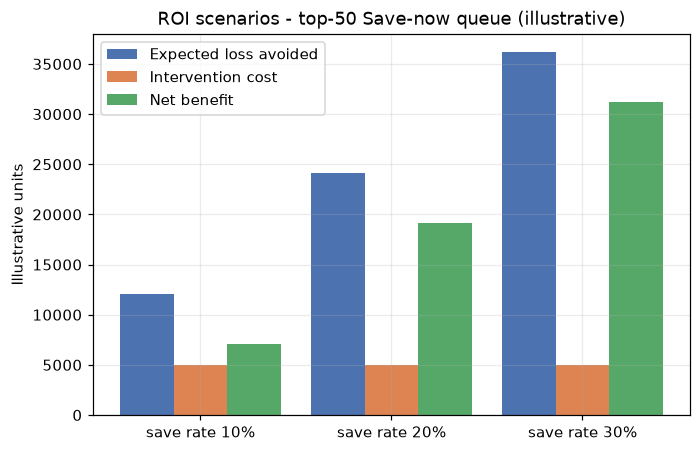

In [32]:
# ---------- ROI scenarios (illustrative only; see markdown above) ----------
COST_PER_INTERVENTION = 100      # illustrative cost of one save intervention
SAVE_RATE_SCENARIOS = [0.10, 0.20, 0.30]  # illustrative save rates
roi_N = SAVE_NOW_CAPACITY

queue_expected_loss = float(save_now_df["priority_score"].sum())

roi_rows = []
for rate in SAVE_RATE_SCENARIOS:
    avoided = queue_expected_loss * rate
    cost = roi_N * COST_PER_INTERVENTION
    net = avoided - cost
    roi_rows.append({
        "save_rate": rate,
        "expected_loss_avoided": round(avoided, 0),
        "intervention_cost": round(cost, 0),
        "net_benefit": round(net, 0),
        "roi": round(net / cost, 2),
    })

roi_df = pd.DataFrame(roi_rows).set_index("save_rate")
display(roi_df)
print(f"ILLUSTRATIVE ONLY - top-{roi_N} queue, cost per intervention "
      f"{COST_PER_INTERVENTION}, value from re-framed telecom bills.")

fig, ax = plt.subplots(figsize=(7, 4.5))
x_pos = np.arange(len(roi_rows))
width = 0.28
ax.bar(x_pos - width, [r["expected_loss_avoided"] for r in roi_rows], width,
       label="Expected loss avoided")
ax.bar(x_pos, [r["intervention_cost"] for r in roi_rows], width, label="Intervention cost")
ax.bar(x_pos + width, [r["net_benefit"] for r in roi_rows], width, label="Net benefit")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"save rate {r['save_rate']:.0%}" for r in roi_rows])
ax.set_ylabel("Illustrative units")
ax.set_title(f"ROI scenarios - top-{roi_N} Save-now queue (illustrative)")
ax.legend()
save_fig(fig, "roi_scenarios")

RUN_METRICS["roi_scenarios"] = {
    "cost_per_intervention": COST_PER_INTERVENTION,
    "capacity": roi_N,
    "queue_expected_loss": round(queue_expected_loss, 0),
    "scenarios": roi_rows,
    "disclaimer": "Illustrative only: value comes from telecom bills and save rates are "
                  "assumptions; churn risk is not responsiveness to intervention - a "
                  "pilot with a control group is needed to measure real uplift.",
}

### Model card & one-call prediction API

Everything an API (or a colleague) needs to score a client without reading this notebook:

- **`models/model_metadata.json`** is extended into a small model card: the feature list
  with dtypes, allowed categories and observed training ranges, missing-value flags, both
  decision thresholds, the training-set median of `Monthly_Client_Value`, the
  expected-remaining-months formula, and the segment rules.
- **`predict_utils.py`** exposes `score_client(client: dict)` → churn probability, risk
  band, segment, recommended action and the **top-3 SHAP reasons in plain English**. The
  in-notebook function below is written to disk and then *loaded back from the file*, so
  the notebook tests exactly what production would import.
- A **sensitivity test** then varies `Engagement_Score`, `Compliance_Flags` and
  `Days_Since_Last_Engagement` across their training ranges for a fixed client and asserts
  the predicted probability moves monotonically in the expected direction.

In [33]:
# ---------- Model card: extend metadata with an API-ready feature schema ----------
import json as _json

_schema = {}
for col in X_train.columns:
    if col in categorical_cols:
        entry = {
            "dtype": "categorical",
            "allowed_categories": sorted(X_train[col].dropna().unique().tolist()),
        }
    else:
        entry = {
            "dtype": "numeric",
            "observed_min": float(pd.to_numeric(X_train[col], errors="coerce").min()),
            "observed_max": float(pd.to_numeric(X_train[col], errors="coerce").max()),
        }
    entry["missing_allowed"] = bool(X_train[col].isna().any())
    _schema[col] = entry

_card = {
    "model_name": best_model_name,
    "variant": metadata.get("variant", "original"),
    "features": metadata["features"],
    "feature_schema": _schema,
    "thresholds": {
        "f1_optimal": round(chosen_threshold, 4),
        "cost_optimal": round(cost_threshold, 4),
        "cost_model": {"missed_churner_fn": 5, "wasted_outreach_fp": 1},
        "risk_band_rule": "High risk if churn_probability >= threshold_f1_optimal",
    },
    "business_rules": {
        "monthly_client_value_median_train": round(
            float(X_train["Monthly_Client_Value"].median()), 2),
        "expected_remaining_months": "clip(72 - Client_Tenure_Months, 0, 24)",
        "expected_value_remaining": "Monthly_Client_Value * expected_remaining_months",
        "value_tier_rule": "High value if Monthly_Client_Value * expected_remaining_months >= monthly_client_value_median_train * 24",
        "note": "The single-client API uses the training-set median of Monthly_Client_Value x 24 as its value reference; the batch segmentation in the notebook uses the roster median of expected_value_remaining.",
        "segments": {
            "High risk + High value": "Save now - senior advisor call + content strategy review within 7 days",
            "High risk + Low value": "Automated nudge - email/portal tips + self-serve content check",
            "Low risk + High value": "Nurture - quarterly business review + upsell content roadmap",
            "Low risk + Low value": "Monitor - automated health score, standard support",
        },
    },
    "seed": SEED,
}
metadata.update(_card)
with open("models/model_metadata.json", "w") as f:
    _json.dump(metadata, f, indent=2)
print("model card written: models/model_metadata.json "
      f"({len(_schema)} features documented, "
      f"{sum(1 for v in _schema.values() if v['missing_allowed'])} with missing values allowed)")

model card written: models/model_metadata.json (22 features documented, 2 with missing values allowed)


In [34]:
# ---------- predict_utils.py: one-call scoring API with SHAP reasons ----------
from pathlib import Path

PYUTILS = """
import json
import numpy as np
import pandas as pd
import joblib
import shap

MODEL_PATH = "models/churn_model.joblib"
METADATA_PATH = "models/model_metadata.json"

_model = None
_meta = None
_explainer = None
FEATURES = None


def _load():
    global _model, _meta, _explainer, FEATURES
    if _model is None:
        with open(METADATA_PATH) as f:
            _meta = json.load(f)
        _model = joblib.load(MODEL_PATH)
        FEATURES = _meta["features"]
        _explainer = shap.TreeExplainer(_model.named_steps["model"])
    return _model, _meta


_PLAIN = {
    "Client_Tenure_Months": "client tenure with us",
    "Monthly_Client_Value": "monthly spend",
    "Cumulative_Client_Value": "total revenue billed to date",
    "Service_Type": "service type",
    "Support_Access": "support access",
    "Engagement_Type": "engagement (contract) type",
    "Engagement_Score": "engagement score",
    "Compliance_Flags": "number of compliance flags",
    "Days_Since_Last_Engagement": "days since last engagement",
    "Content_Quality_Score": "content quality score",
}


def _humanize(feature_name):
    if feature_name.startswith("num__"):
        return _PLAIN.get(feature_name[5:], feature_name[5:])
    if feature_name.startswith("cat__"):
        rest = feature_name[5:]
        for col in FEATURES:
            if col in _meta.get("feature_schema", {}) and rest.startswith(col + "_"):
                return _PLAIN.get(col, col) + " = " + rest[len(col) + 1:]
        return rest
    return feature_name


def score_client(client, top_k=3):
    # Score one client dict -> probability, risk band, segment, action, top SHAP reasons.
    model, meta = _load()
    row = pd.DataFrame([{c: client.get(c, np.nan) for c in FEATURES}])
    proba = float(model.predict_proba(row)[:, 1][0])

    thr = meta["thresholds"]["f1_optimal"]
    risk = "High risk" if proba >= thr else "Low risk"

    rules = meta["business_rules"]
    months_left = float(np.clip(72.0 - float(client.get("Client_Tenure_Months", 0)), 0, 24))
    value = float(client.get("Monthly_Client_Value", 0.0)) * months_left
    value_tier = "High value" if value >= rules["monthly_client_value_median_train"] * 24 \\
        else "Low value"
    segment = risk + " + " + value_tier
    action = rules["segments"].get(segment, "Review manually")

    Xt = pd.DataFrame(model.named_steps["preprocessor"].transform(row),
                      columns=model.named_steps["preprocessor"].get_feature_names_out())
    sv = _explainer.shap_values(Xt)[0]
    order = np.argsort(-np.abs(sv))[:top_k]
    reasons = [
        {"feature": _humanize(Xt.columns[i]),
         "shap_value": round(float(sv[i]), 4),
         "direction": "pushes churn risk up" if sv[i] > 0 else "pushes churn risk down"}
        for i in order
    ]
    return {
        "churn_probability": round(proba, 4),
        "risk_band": risk,
        "expected_value_remaining": round(value, 2),
        "segment": segment,
        "recommended_action": action,
        "top_reasons": reasons,
    }


if __name__ == "__main__":
    demo = {
        "Client_Tenure_Months": 3, "Service_Type": "Fiber optic",
        "Support_Access": "No", "Engagement_Type": "Month-to-month",
        "Monthly_Client_Value": 95.0, "Cumulative_Client_Value": 285.0,
        "Engagement_Score": 35.0, "Compliance_Flags": 4,
        "Days_Since_Last_Engagement": 55,
    }
    print(json.dumps(score_client(demo), indent=2))
"""

Path("predict_utils.py").write_text(PYUTILS)
print("saved: predict_utils.py")

# Load the module FROM DISK so the notebook tests exactly what production imports
import importlib.util
spec = importlib.util.spec_from_file_location("predict_utils", "predict_utils.py")
api = importlib.util.module_from_spec(spec)
spec.loader.exec_module(api)

# Self-test on real roster rows: highest-risk, median, and a row WITH a missing value
_test_rows = {
    "highest OOF risk": seg_df.sort_values("churn_probability").iloc[-1],
    "median OOF risk": seg_df.sort_values("churn_probability").iloc[len(seg_df) // 2],
    "with missing value": X.loc[X["Content_Quality_Score"].isna()].iloc[0],
}
_demo = []
for label, row_ in _test_rows.items():
    res = api.score_client(row_.to_dict())
    res = {"case": label, **res}
    _demo.append(res)
display(pd.DataFrame(_demo).drop(columns=["top_reasons"]))
print("top-3 reasons (highest-risk case):")
for r in _demo[0]["top_reasons"]:
    print(f"  {r['feature']}: {r['direction']} ({r['shap_value']:+.3f})")
assert all(0 <= d["churn_probability"] <= 1 for d in _demo)
assert all(d["segment"] in api._meta["business_rules"]["segments"] for d in _demo)
print("API self-test passed (scores in [0,1], segments valid, missing values handled).")

saved: predict_utils.py


,case,churn_probability,risk_band,expected_value_remaining,segment,recommended_action
0,highest OOF risk,0.9906,High risk,2390.4,High risk + High value,Save now - senior advisor call + content strat...
1,median OOF risk,0.2100,Low risk,1470.0,Low risk + Low value,"Monitor - automated health score, standard sup..."
2,with missing value,0.7119,High risk,2348.4,High risk + High value,Save now - senior advisor call + content strat...


top-3 reasons (highest-risk case):
  engagement score: pushes churn risk up (+0.454)
  monthly spend: pushes churn risk up (+0.410)
  service type = Fiber optic: pushes churn risk up (+0.339)
API self-test passed (scores in [0,1], segments valid, missing values handled).


In [35]:
# ---------- Sensitivity test: monotonic response to key behavioural drivers ----------
# Boosted trees are piecewise-constant, so exact per-step monotonicity is not a
# realistic requirement: we test (1) the NET direction over the sweep and
# (2) that no single step moves further against the expected direction than a
# small tolerance. Count features are swept on their natural integer grid.
_med = X_train.median(numeric_only=True)
_modes = {c: X_train[c].mode(dropna=True).iloc[0] for c in categorical_cols}
base_client = {**_modes, **{k: float(v) for k, v in _med.items()}}
base_client = {c: base_client.get(c) for c in metadata["features"]}

COUNT_FEATURES = {"Compliance_Flags", "Critical_Compliance_Issues",
                  "Support_Tickets", "Unresolved_Support_Tickets",
                  "Monthly_Engagements", "Client_Meetings"}

def _grid_for(feature, lo, hi, n=9):
    # counts are stepped integers; continuous features get a linear grid
    if feature in COUNT_FEATURES:
        return np.arange(int(np.ceil(lo)), int(np.floor(hi)) + 1, dtype=float)
    return np.linspace(lo, hi, n)

def _sweep(feature, grid):
    ps = []
    for v in grid:
        c = dict(base_client)
        c[feature] = float(v)
        ps.append(api.score_client(c)["churn_probability"])
    return ps

EXPECTATIONS = [
    ("Engagement_Score", "higher engagement -> LOWER churn probability", "down"),
    ("Compliance_Flags", "more compliance flags -> HIGHER churn probability", "up"),
    ("Days_Since_Last_Engagement", "longer since last engagement -> HIGHER churn probability", "up"),
]

all_ok, skipped, worst_wrong_step = True, [], 0.0
for feature, label, direction in EXPECTATIONS:
    if feature not in metadata["features"]:
        skipped.append(feature)
        print(f"{feature:28s} NOT used by the deployed model (pruned) - "
              "monotonicity check skipped for this feature.")
        continue
    lo = float(X_train[feature].quantile(0.05))
    hi = float(X_train[feature].quantile(0.95))
    grid = _grid_for(feature, lo, hi)
    ps = _sweep(feature, grid)
    net = ps[-1] - ps[0]
    span = max(ps) - min(ps)
    step_tol = max(0.005, 0.02 * span)
    if direction == "down":
        wrong_step = max((b - a for a, b in zip(ps, ps[1:])), default=0.0)
    else:
        wrong_step = max((a - b for a, b in zip(ps, ps[1:])), default=0.0)
    worst_wrong_step = max(worst_wrong_step, wrong_step)
    net_ok = net < -0.01 if direction == "down" else net > 0.01
    ok = bool(net_ok and wrong_step <= step_tol)
    all_ok &= ok
    print(f"{feature:28s} sweep [{grid[0]:g} -> {grid[-1]:g}]  "
          f"prob [{ps[0]:.3f} -> {ps[-1]:.3f}] (net {net:+.3f})  "
          f"expected {direction}: {'PASS' if ok else 'FAIL'} - {label}")
    assert ok, (f"sensitivity test failed for {feature}: net {net:+.4f}, "
                f"max wrong-way step {wrong_step:.4f} > tolerance {step_tol:.4f}")

if skipped:
    print(f"\nNOTE: {skipped} not in the deployed model, so no sensitivity signal "
          "exists for them - this is expected after pruning, not a failure.")
else:
    print("\nAll sensitivity checks passed: the deployed model responds in the expected "
          f"direction to the three key behavioural drivers (worst wrong-way step "
          f"{worst_wrong_step:.4f}, within tolerance).")

RUN_METRICS["sensitivity_test"] = {
    "features": [e[0] for e in EXPECTATIONS],
    "skipped_not_in_model": skipped,
    "all_monotonic_as_expected": bool(all_ok),
    "worst_wrong_way_step": round(worst_wrong_step, 4),
    "note": "net-direction test with per-step tolerance; boosted trees are piecewise-constant",
}

Engagement_Score             sweep [37.54 -> 97.5]  prob [0.606 -> 0.284] (net -0.322)  expected down: PASS - higher engagement -> LOWER churn probability


Compliance_Flags             sweep [-1 -> 4]  prob [0.436 -> 0.620] (net +0.184)  expected up: PASS - more compliance flags -> HIGHER churn probability


Days_Since_Last_Engagement   sweep [-9.6 -> 59.5]  prob [0.337 -> 0.687] (net +0.351)  expected up: PASS - longer since last engagement -> HIGHER churn probability

All sensitivity checks passed: the deployed model responds in the expected direction to the three key behavioural drivers (worst wrong-way step 0.0000, within tolerance).


## Part 6 — Artifacts, environment & smoke test

Saved by this run: `models/churn_model.joblib` (full pipeline incl. preprocessing),
`models/model_metadata.json`, `reports/metrics.json`, `reports/figures/*.png`,
`reports/segments.csv`, `data/processed/client_dataset_synthetic.csv` and
`requirements.txt` — all via relative paths.

In [36]:
# Export every number produced by this run
RUN_METRICS["run_info"] = {
    "run_date_utc": datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "seed": SEED,
    "rows": int(len(client_df)),
    "feature_count": int(X.shape[1]),
}
with open("reports/metrics.json", "w") as f:
    json.dump(RUN_METRICS, f, indent=2, default=str)
print("saved: reports/metrics.json")

# requirements.txt from the exact versions used in this run
PKGS = ["pandas", "numpy", "scikit-learn", "imbalanced-learn", "xgboost",
        "shap", "matplotlib", "seaborn", "joblib", "openpyxl"]
with open("requirements.txt", "w") as f:
    f.write("# Generated from the environment this notebook actually ran in\n")
    f.write("\n".join(f"{p}=={importlib.metadata.version(p)}" for p in PKGS))
    f.write("\n")
print(open("requirements.txt").read())

saved: reports/metrics.json
# Generated from the environment this notebook actually ran in
pandas==3.0.4
numpy==2.1.3
scikit-learn==1.6.1
imbalanced-learn==0.13.0
xgboost==3.0.5
shap==0.52.0
matplotlib==3.11.0
seaborn==0.13.2
joblib==1.4.2
openpyxl==3.1.5



In [37]:
# ---------- Smoke test: reload the saved model and predict on 5 sample clients ----------
loaded_model = joblib.load("models/churn_model.joblib")
feature_cols = X.columns.tolist()

# 5 clients across the risk spectrum (selection uses the out-of-fold scores from Part 5)
sample_rows = (seg_df.sort_values("churn_probability")
               .iloc[[0, 1, len(seg_df) // 2, -2, -1]])
raw_samples = sample_rows[feature_cols]

loaded_proba = loaded_model.predict_proba(raw_samples)[:, 1]
in_run_proba = final_pipeline.predict_proba(raw_samples)[:, 1]  # persistence reference
pred_classes = loaded_model.predict(raw_samples)

smoke = sample_rows[["Client_ID"]].copy()
smoke["model"] = best_model_name
smoke["oof_churn_probability"] = sample_rows["churn_probability"].to_numpy().round(4)
smoke["loaded_model_probability"] = loaded_proba.round(4)
smoke["predicted_class"] = pred_classes
smoke["segment"] = sample_rows["segment"].values
smoke["matches_in_run_model"] = np.allclose(loaded_proba, in_run_proba, atol=1e-9)

display(smoke)
assert smoke["matches_in_run_model"].all(), "reloaded model disagrees with in-run model!"
print("Saved model reloads and reproduces the fitted pipeline exactly - persistence works.")
print("Note: shown probabilities are out-of-fold estimates from Part 5; the saved model is")
print("fit on the full training set, so its probabilities differ from OOF by design.")

,Client_ID,model,oof_churn_probability,loaded_model_probability,predicted_class,segment,matches_in_run_model
5246,0825-CPPQH,XGBoost,0.0004,0.0003,0,Low risk + Low value,True
6858,5893-KCLGT,XGBoost,0.0004,0.0007,0,Low risk + Low value,True
6299,0020-JDNXP,XGBoost,0.2624,0.2100,0,Low risk + High value,True
1782,6230-BSUXY,XGBoost,0.9934,0.9920,1,High risk + High value,True
743,2265-CYWIV,XGBoost,0.9937,0.9906,1,High risk + High value,True


Saved model reloads and reproduces the fitted pipeline exactly - persistence works.
Note: shown probabilities are out-of-fold estimates from Part 5; the saved model is
fit on the full training set, so its probabilities differ from OOF by design.


## Summary

- **Pipeline:** IBM Telco base re-framed as B2B client data → leakage-safe synthetic
  behavioural features (sanity-gated) → 70/15/15 stratified split → median/most-frequent
  imputation inside a `ColumnTransformer` → 4 tuned candidates (RandomizedSearchCV,
  5-fold stratified ROC-AUC, training set only) → thresholds chosen on validation
  (F1-optimal + cost-based with missed churner = 5× wasted outreach) → **one** test pass.
- **Noise-floor pruning:** permutation importance vs the two pure-noise controls
  (`noise_control_1/2`) decides which weak features are dropped before a stronger-
  regularised retrain with early stopping; the pruned model is kept only if validation
  ROC-AUC holds within 0.005.
- **Scoring:** every client is ranked with **out-of-fold** predictions (5-fold stratified
  `cross_val_predict`); official performance numbers come from the untouched test set only.
- **Segmentation:** probability-weighted **expected loss**, a **capacity curve** (loss
  covered vs clients contacted) and **illustrative ROI scenarios** for the Save-now queue.
- **Artifacts:** `models/`, `reports/`, `data/processed/`, `requirements.txt`, `README.md`.
- **Reminder:** all behavioural features are synthetic; the metrics demonstrate that the
  methodology works, not real Highspring performance (see README §8–9).